# Box Inflection Study + ConvLSTM

## Tensor generation, flat-linear inflection, annual spatial z-scores, Adapted Shreya ConvLSTM

## 0. Config

Edit the configuration cell below first. In particular:

- `LAT_MIN`, `LAT_MAX`, `LON_MIN`,`LON_MAX` to choose box
- `SELECTED_FEATURES = None` uses every configured variable
- `INFLECTION_YEAR_OVERRIDE = None` uses avg fitted break year (or input different year)
- `REBUILD_TENSOR = False` reuses existing tensor if available
- `TRAIN_CONVLSTM = False` uses saved model

In [1]:
from pathlib import Path
import json
import logging
import math
import os
import pickle
import random
import re
import warnings

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from IPython.display import display
from scipy.interpolate import griddata
from scipy.optimize import curve_fit

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings(
    "ignore",
    message="Converting non-nanosecond precision datetime values to nanosecond precision.*",
    category=UserWarning,
)
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
logging.getLogger("tensorflow").setLevel(logging.ERROR)
pd.set_option("display.max_columns", None)
plt.style.use("seaborn-v0_8-whitegrid")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

In [2]:
DATA_ROOT = Path(r"C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets")
ORAS5_DIR = DATA_ROOT / "ORAS5" / "BOXED"
ERA5_DIR = DATA_ROOT / "ERA5"

# Decides which variables are kept
MIN_SPATIAL_COVERAGE = 0.80
MIN_ADEQUATE_MONTH_FRACTION = 0.90

# BOX
LAT_MIN, LAT_MAX = 55, 64 # Labrador Sea
LON_MIN, LON_MAX = -60, -50
DLAT, DLON = 0.5, 0.5

SELECTED_FEATURES = None
REBUILD_TENSOR = False

# Inflection
INFLECTION_BREAK_GUESS = 1980
MIN_MONTHS_PER_YEAR = 10
MIN_SEGMENT_YEARS = 5
INFLECTION_YEAR_OVERRIDE = None  # Example: 1982

# Statistical method
MIN_PRE_INFLECTION_YEARS = 3

# Adapted Shreya
LOOKBACK = 12
VALIDATION_YEARS = 5
CONVLSTM_FORECAST_END = None  # None goes until final observed month (or use "2025-12-01" format)
TRAIN_CONVLSTM = True
CONVLSTM_EPOCHS = 50
CONVLSTM_BATCH_SIZE = 4
CONVLSTM_LEARNING_RATE = 1e-3
CONVLSTM_FILTERS = (32, 32, 16)

NETCDF_ENGINE = "h5netcdf"

ORAS5_VAR_META = {
    "sst": {"token": "sst", "depth_mode": None},
    "salinity": {"token": "so_salinity", "depth_mode": "0_100m"},
    "thetao": {"token": "thetao", "depth_mode": "0_100m"},
    "qnet": {"token": "heat", "depth_mode": None},
    "u_current": {"token": "u_zonal", "depth_mode": "0_100m"},
    "v_current": {"token": "v_meridional", "depth_mode": "0_100m"},
}

ERA5_FILES = {
    "era5_sst": ERA5_DIR / "sst.nc",
    "era5_u10": ERA5_DIR / "u10_v10.nc",
    "era5_v10": ERA5_DIR / "u10_v10.nc",
    "era5_runoff": ERA5_DIR / "runoff_full.nc",
    "era5_d2m": ERA5_DIR / "all_others.nc",
    "era5_skt": ERA5_DIR / "all_others.nc",
    "era5_stl2": ERA5_DIR / "all_others.nc",
    "era5_swvl1": ERA5_DIR / "all_others.nc",
}

ERA5_VAR_NAMES = {
    "era5_sst": "sst",
    "era5_u10": "u10",
    "era5_v10": "v10",
    "era5_runoff": "ro",
    "era5_d2m": "d2m",
    "era5_skt": "skt",
    "era5_stl2": "stl2",
    "era5_swvl1": "swvl1",
}

FEATURE_UNITS = {
    "sst": "degC",
    "salinity": "PSU",
    "thetao": "degC",
    "qnet": "W m-2",
    "u_current": "m s-1",
    "v_current": "m s-1",
    "era5_sst": "degC",
    "era5_u10": "m s-1",
    "era5_v10": "m s-1",
    "era5_runoff": "m",
    "era5_d2m": "degC",
    "era5_skt": "degC",
    "era5_stl2": "degC",
    "era5_swvl1": "m3 m-3",
}

In [3]:
if not (-90 <= LAT_MIN < LAT_MAX <= 90):
    raise ValueError("Require -90 <= LAT_MIN < LAT_MAX <= 90.")
if not (-180 <= LON_MIN < LON_MAX <= 180):
    raise ValueError("Require -180 <= LON_MIN < LON_MAX <= 180.")
if DLAT <= 0 or DLON <= 0:
    raise ValueError("DLAT and DLON must be positive.")

REGION = {
    "lat_min": float(LAT_MIN),
    "lat_max": float(LAT_MAX),
    "lon_min": float(LON_MIN),
    "lon_max": float(LON_MAX),
}

def coordinate_label(value, positive_letter, negative_letter):
    direction = positive_letter if value >= 0 else negative_letter
    number = f"{abs(value):g}".replace(".", "p")
    return f"{number}{direction}"

box_label = "_".join([
    coordinate_label(LAT_MIN, "N", "S"),
    coordinate_label(LAT_MAX, "N", "S"),
    coordinate_label(LON_MIN, "E", "W"),
    coordinate_label(LON_MAX, "E", "W"),
    f"{DLAT:g}x{DLON:g}deg".replace(".", "p"),
])

OUTPUT_DIR = DATA_ROOT / "Processed" / f"combined_box_study_{box_label}"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
TENSOR_PATH = OUTPUT_DIR / f"monthly_tensor_{box_label}.nc"

print("Region:", REGION)
print("Variables:", "all configured" if SELECTED_FEATURES is None else SELECTED_FEATURES)
print("Tensor cache:", TENSOR_PATH)
print("Analysis outputs:", OUTPUT_DIR)

Region: {'lat_min': 55.0, 'lat_max': 64.0, 'lon_min': -60.0, 'lon_max': -50.0}
Variables: all configured
Tensor cache: C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\Processed\combined_box_study_55N_64N_60W_50W_0p5x0p5deg\monthly_tensor_55N_64N_60W_50W_0p5x0p5deg.nc
Analysis outputs: C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\Processed\combined_box_study_55N_64N_60W_50W_0p5x0p5deg


## 1. Generate/load the monthly tensor

In [4]:
FILE_RE = re.compile(r"ORAS5_(\d{4})_(\d{2})_(.+?)_boxed\.nc$")

def open_nc(path):
    path = Path(path)
    errors = []
    for engine in (NETCDF_ENGINE, "netcdf4", "scipy"):
        try:
            return xr.open_dataset(path, engine=engine)
        except Exception as exc:
            errors.append(f"{engine}: {exc}")
    raise OSError(f"Could not open {path}\n" + "\n".join(errors))

def files_for_token(data_dir, token):
    return sorted(
        path for path in Path(data_dir).rglob("*.nc")
        if FILE_RE.search(path.name) and token in path.name
    )

def time_from_filename(path):
    match = FILE_RE.search(Path(path).name)
    if match is None:
        raise ValueError(f"Unexpected ORAS5 filename: {Path(path).name}")
    return pd.Timestamp(int(match.group(1)), int(match.group(2)), 1)

def find_main_var(ds):
    ignore = {
        "time", "time_counter", "valid_time", "nav_time",
        "lat", "lon", "latitude", "longitude", "nav_lat", "nav_lon",
        "depth", "deptht", "depthu", "depthv", "nav_lev",
        "bnds", "bounds", "nbnds", "nv", "number", "expver",
    }
    candidates = []
    for name, da in ds.data_vars.items():
        try:
            numeric = np.issubdtype(da.dtype, np.number)
        except TypeError:
            numeric = False
        if name not in ignore and numeric and da.ndim >= 2:
            candidates.append((da.size, name))
    if not candidates:
        raise ValueError(f"No usable numeric field. data_vars={list(ds.data_vars)}")
    return max(candidates)[1]

def clean_numeric_array(da):
    da = da.where(np.isfinite(da))
    for attr_name in ("_FillValue", "missing_value"):
        value = da.attrs.get(attr_name)
        if value is not None and np.ndim(value) == 0:
            da = da.where(da != value)
    da = da.where(np.abs(da) < 1e10)

    for dim in ("time_counter", "valid_time", "nav_time", "time"):
        if dim in da.dims and da.sizes[dim] == 1:
            da = da.isel({dim: 0}, drop=True)
    for dim in ("bnds", "bounds", "nbnds", "nv", "number", "expver"):
        if dim in da.dims:
            da = da.isel({dim: 0}, drop=True)
    return da.squeeze(drop=True).astype(np.float32)

def depth_reduce_if_needed(da, ds, depth_mode):
    if depth_mode is None:
        return da
    for zname in ("depth", "deptht", "depthu", "depthv", "nav_lev"):
        if zname not in da.dims:
            continue
        if zname in da.coords:
            z = da[zname]
        elif zname in ds:
            z = ds[zname]
        else:
            z = xr.DataArray(np.arange(da.sizes[zname]), dims=[zname])
        if depth_mode == "0_100m":
            selected = da.where((z >= 0) & (z <= 100), drop=True)
            if selected.sizes.get(zname, 0) == 0:
                raise ValueError("No depth levels between 0 and 100 m.")
            return selected.mean(zname, skipna=True)
    return da

def obtain_nav_coordinates(da, ds):
    lat = lon = None
    for name in ("nav_lat", "latitude", "lat"):
        if name in da.coords:
            lat = da[name].values
            break
        if name in ds.variables:
            lat = ds[name].values
            break
    for name in ("nav_lon", "longitude", "lon"):
        if name in da.coords:
            lon = da[name].values
            break
        if name in ds.variables:
            lon = ds[name].values
            break
    if lat is None or lon is None:
        raise ValueError("No usable latitude/longitude coordinates found.")
    return np.squeeze(lat), np.squeeze(lon)

def target_grid(region=REGION, dlat=DLAT, dlon=DLON):
    lats = np.arange(region["lat_min"], region["lat_max"] + dlat / 2, dlat)
    lons = np.arange(region["lon_min"], region["lon_max"] + dlon / 2, dlon)
    return lats, lons

def regrid_oras5_to_regular(da, ds, region=REGION, dlat=DLAT, dlon=DLON):
    nav_lat, nav_lon = obtain_nav_coordinates(da, ds)
    nav_lon = np.where(nav_lon > 180, nav_lon - 360, nav_lon)
    values = np.squeeze(da.values).astype(np.float32)

    if nav_lat.ndim == 1 and nav_lon.ndim == 1:
        nav_lon, nav_lat = np.meshgrid(nav_lon, nav_lat)
    if values.shape != nav_lat.shape:
        if values.T.shape == nav_lat.shape:
            values = values.T
        else:
            raise ValueError(
                f"Grid mismatch: values={values.shape}, coordinates={nav_lat.shape}"
            )

    valid = (
        np.isfinite(values) & np.isfinite(nav_lat) & np.isfinite(nav_lon)
        & (np.abs(values) < 1e10)
        & (nav_lat >= region["lat_min"] - 1)
        & (nav_lat <= region["lat_max"] + 1)
        & (nav_lon >= region["lon_min"] - 1)
        & (nav_lon <= region["lon_max"] + 1)
    )
    if valid.sum() < 4:
        raise ValueError(f"Only {valid.sum()} valid source grid points.")

    target_lats, target_lons = target_grid(region, dlat, dlon)
    lon2d, lat2d = np.meshgrid(target_lons, target_lats)
    points = np.column_stack((nav_lon[valid], nav_lat[valid]))
    source_values = values[valid]
    linear = griddata(points, source_values, (lon2d, lat2d), method="linear")
    nearest = griddata(points, source_values, (lon2d, lat2d), method="nearest")
    result = np.where(np.isfinite(linear), linear, nearest)
    return xr.DataArray(
        result.astype(np.float32), dims=("lat", "lon"),
        coords={"lat": target_lats, "lon": target_lons}, name=da.name,
    )

def standardise_era5_time(ds):
    if "valid_time" in ds.coords:
        ds = ds.rename({"valid_time": "time"})
    elif "time_counter" in ds.coords:
        ds = ds.rename({"time_counter": "time"})
    if "time" not in ds.coords:
        raise ValueError(f"No time coordinate. coords={list(ds.coords)}")
    return ds.assign_coords(time=pd.to_datetime(ds.time.values))

def load_era5_variable(path, var_name, feature_name, region=REGION):
    with open_nc(path) as ds:
        ds = standardise_era5_time(ds)
        rename = {}
        if "latitude" in ds.coords:
            rename["latitude"] = "lat"
        if "longitude" in ds.coords:
            rename["longitude"] = "lon"
        if rename:
            ds = ds.rename(rename)
        if var_name not in ds.data_vars:
            raise ValueError(
                f"{var_name!r} not found in {Path(path).name}; "
                f"available={list(ds.data_vars)}"
            )
        da = ds[var_name]
        for dim in list(da.dims):
            if dim not in ("time", "lat", "lon"):
                da = da.isel({dim: 0}, drop=True)
        da = da.assign_coords(lon=xr.where(da.lon > 180, da.lon - 360, da.lon))
        da = da.sortby("lat").sortby("lon")
        da = da.sel(
            lat=slice(region["lat_min"], region["lat_max"]),
            lon=slice(region["lon_min"], region["lon_max"]),
        )
        da = da.where(np.abs(da) < 1e10).resample(time="MS").mean(skipna=True)
        if feature_name in {"era5_sst", "era5_d2m", "era5_skt", "era5_stl2"}:
            da = da - 273.15
        target_lats, target_lons = target_grid(region)
        return da.interp(lat=target_lats, lon=target_lons).astype(np.float32).load()

In [5]:
def build_combined_monthly_tensor():
    selected = None if SELECTED_FEATURES is None else set(SELECTED_FEATURES)
    oras_meta = {
        name: meta for name, meta in ORAS5_VAR_META.items()
        if selected is None or name in selected
    }
    era_files = {
        name: path for name, path in ERA5_FILES.items()
        if selected is None or name in selected
    }
    requested = list(oras_meta) + list(era_files)
    if not requested:
        raise ValueError("No configured variables were selected.")

    oras5_monthly = None
    skipped_oras5 = []
    if oras_meta:
        print("Indexing ORAS5 files...")
        file_dict = {}
        for feature_name, meta in oras_meta.items():
            paths = files_for_token(ORAS5_DIR, meta["token"])
            file_dict[feature_name] = {time_from_filename(path): path for path in paths}
            print(f"  {feature_name:12s}: {len(paths)} files")
        missing = [name for name, paths in file_dict.items() if not paths]
        if missing:
            raise FileNotFoundError(f"No matching ORAS5 files for: {missing}")

        common_times = sorted(set.intersection(*[set(v) for v in file_dict.values()]))
        print(f"ORAS5 common range: {common_times[0]:%Y-%m} to {common_times[-1]:%Y-%m}")
        monthly_fields = []
        for index, timestamp in enumerate(common_times, start=1):
            if index == 1 or index % 24 == 0 or index == len(common_times):
                print(f"  ORAS5 {index}/{len(common_times)}: {timestamp:%Y-%m}")
            feature_arrays = []
            failed = False
            for feature_name, meta in oras_meta.items():
                path = file_dict[feature_name][timestamp]
                try:
                    with open_nc(path) as ds:
                        da = ds[find_main_var(ds)]
                        da = depth_reduce_if_needed(da, ds, meta["depth_mode"])
                        da = clean_numeric_array(da)
                        da = regrid_oras5_to_regular(da, ds)
                        if feature_name in {"sst", "thetao"}:
                            mean_value = float(da.mean(skipna=True))
                            if np.isfinite(mean_value) and mean_value > 100:
                                da = da - 273.15
                        feature_arrays.append(da.load())
                except Exception as exc:
                    skipped_oras5.append((str(timestamp.date()), feature_name, str(exc)))
                    print(f"    Skipping {timestamp:%Y-%m}: {feature_name}: {exc}")
                    failed = True
                    break
            if failed:
                continue
            month = xr.concat(
                feature_arrays,
                dim=xr.IndexVariable("feature", list(oras_meta)),
            ).expand_dims(
                time=np.array([timestamp.to_datetime64()], dtype="datetime64[ns]")
            )
            monthly_fields.append(month)

        if not monthly_fields:
            raise RuntimeError("No complete ORAS5 months were created.")
        oras5_monthly = xr.concat(
            monthly_fields, dim="time", coords="minimal",
            compat="override", join="override",
        )

    era5_monthly = None
    skipped_era5 = []
    if era_files:
        print("Loading ERA5 variables...")
        era_arrays = []
        for feature_name, path in era_files.items():
            try:
                print(f"  {feature_name} <- {path.name}")
                da = load_era5_variable(
                    path, ERA5_VAR_NAMES[feature_name], feature_name
                )
            except Exception as exc:
                skipped_era5.append((feature_name, str(exc)))
                print(f"    Could not load {feature_name}: {exc}")
                if oras5_monthly is None:
                    continue
                target_lats, target_lons = target_grid()
                da = xr.DataArray(
                    np.full(
                        (len(oras5_monthly.time), len(target_lats), len(target_lons)),
                        np.nan, dtype=np.float32,
                    ),
                    dims=("time", "lat", "lon"),
                    coords={
                        "time": oras5_monthly.time.values,
                        "lat": target_lats,
                        "lon": target_lons,
                    },
                )
            era_arrays.append(da.expand_dims(feature=[feature_name]))
        if era_arrays:
            era5_monthly = xr.concat(era_arrays, dim="feature", join="outer")

    families = [family for family in (oras5_monthly, era5_monthly) if family is not None]
    if not families:
        raise RuntimeError("No ORAS5 or ERA5 fields could be loaded.")
    if len(families) == 2:
        common_times = np.intersect1d(families[0].time.values, families[1].time.values)
        families = [family.sel(time=common_times) for family in families]

    combined = xr.concat(
        families, dim="feature", coords="minimal", compat="override", join="outer"
    ).sortby("time").transpose("time", "feature", "lat", "lon")
    combined = combined.where(np.abs(combined) < 1e10).astype(np.float32)
    combined.name = "climate"
    combined.attrs.update({
        "description": "Monthly combined ORAS5 and ERA5 tensor",
        "region": json.dumps(REGION),
        "grid_spacing_degrees": f"{DLAT} x {DLON}",
        "requested_features": json.dumps(requested),
        "skipped_oras5": json.dumps(skipped_oras5),
        "skipped_era5": json.dumps(skipped_era5),
    })
    return combined

def load_or_build_tensor():
    if REBUILD_TENSOR or not TENSOR_PATH.exists():
        tensor = build_combined_monthly_tensor()
        encoding = {
            "climate": {
                "zlib": True, "complevel": 4, "shuffle": True,
                "dtype": "float32", "_FillValue": np.float32(np.nan),
            }
        }
        tensor.to_dataset(name="climate").to_netcdf(
            TENSOR_PATH, engine=NETCDF_ENGINE, encoding=encoding
        )
        print("Saved tensor:", TENSOR_PATH)
    else:
        print("Loading cached tensor:", TENSOR_PATH)
        with xr.open_dataset(TENSOR_PATH, engine=NETCDF_ENGINE) as ds:
            tensor = ds["climate" if "climate" in ds.data_vars else next(iter(ds.data_vars))].load()

    tensor = (
        tensor.sortby("time")
        .transpose("time", "feature", "lat", "lon")
        .where(np.abs(tensor) < 1e10)
        .astype(np.float32)
        .assign_coords(feature=tensor.feature.values.astype(str))
    )
    if SELECTED_FEATURES is not None:
        missing = sorted(set(SELECTED_FEATURES) - set(tensor.feature.values.astype(str)))
        if missing:
            raise ValueError(
                f"Selected features are absent from the cache: {missing}. "
                "Set REBUILD_TENSOR=True after checking their source files."
            )
        tensor = tensor.sel(feature=SELECTED_FEATURES)

    quality_rows = []
    retained_features = []

    for feature in tensor.feature.values.astype(str):
        feature_data = tensor.sel(feature=feature)

        # Spatial coverage for every available month
        monthly_spatial_coverage = feature_data.notnull().mean(("lat", "lon"))

        finite_fraction = float(feature_data.notnull().mean().item())
        median_spatial_coverage = float(
            monthly_spatial_coverage.median("time").item()
        )
        adequate_month_fraction = float(
            (
                monthly_spatial_coverage >= MIN_SPATIAL_COVERAGE
            ).mean("time").item()
        )
        standard_deviation = float(feature_data.std(skipna=True).item())

        keep = (
            median_spatial_coverage >= MIN_SPATIAL_COVERAGE
            and adequate_month_fraction >= MIN_ADEQUATE_MONTH_FRACTION
        )

        quality_rows.append({
            "feature": feature,
            "finite_fraction": finite_fraction,
            "median_spatial_coverage": median_spatial_coverage,
            "adequate_month_fraction": adequate_month_fraction,
            "std": standard_deviation,
            "retained": keep,
        })

        if keep:
            retained_features.append(feature)

    tensor_quality = pd.DataFrame(quality_rows)

    removed_features = [
        feature
        for feature in tensor.feature.values.astype(str)
        if feature not in retained_features
    ]

    if removed_features:
        print("Removed features with insufficient coverage:")
        for feature in removed_features:
            print(f"  - {feature}")

    if not retained_features:
        raise ValueError("No features satisfy the coverage requirements.")

    tensor = tensor.sel(feature=retained_features)

    return tensor, tensor_quality

combined_monthly, tensor_quality = load_or_build_tensor()
display(tensor_quality)
print(combined_monthly)
print("Retained features:", combined_monthly.feature.values.astype(str).tolist())
print(
    "Time range:",
    pd.Timestamp(combined_monthly.time.values[0]).strftime("%Y-%m"), "to",
    pd.Timestamp(combined_monthly.time.values[-1]).strftime("%Y-%m"),
)

Loading cached tensor: C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\Processed\combined_box_study_55N_64N_60W_50W_0p5x0p5deg\monthly_tensor_55N_64N_60W_50W_0p5x0p5deg.nc
Removed features with insufficient coverage:
  - era5_u10
  - era5_v10
  - era5_d2m
  - era5_skt
  - era5_stl2
  - era5_swvl1


,feature,finite_fraction,median_spatial_coverage,adequate_month_fraction,std,retained
0,sst,1.000000,1.000000,1.0,2.427455,True
1,salinity,1.000000,1.000000,1.0,0.848497,True
2,thetao,1.000000,1.000000,1.0,1.947981,True
3,qnet,1.000000,1.000000,1.0,311.126373,True
4,u_current,1.000000,1.000000,1.0,0.090418,True
5,v_current,1.000000,1.000000,1.0,0.123397,True
6,era5_sst,0.967419,0.967419,1.0,2.684133,True
7,era5_u10,0.005013,0.005013,0.0,0.639104,False
8,era5_v10,0.005013,0.005013,0.0,0.662888,False
9,era5_runoff,1.000000,1.000000,1.0,0.000471,True


<xarray.DataArray 'climate' (time: 797, feature: 8, lat: 19, lon: 21)> Size: 10MB
array([[[[-1.73389328e+00, -1.71124053e+00, -1.70061827e+00, ...,
           2.97413158e+00,  3.03256440e+00,  3.28612924e+00],
         [-1.74582469e+00, -1.66613889e+00, -1.53231835e+00, ...,
           3.04327703e+00,  3.14700699e+00,  3.24320054e+00],
         [-1.63925123e+00, -1.49325252e+00, -1.39575422e+00, ...,
           2.70818543e+00,  3.11843657e+00,  3.30590892e+00],
         ...,
         [-1.34145424e-01,  1.53409374e+00,  2.95839357e+00, ...,
           1.60862207e+00, -7.69997120e-01, -7.58010983e-01],
         [-8.13775599e-01, -1.23193741e-01,  6.87444329e-01, ...,
          -9.72430944e-01,  3.15388560e-01, -7.58010983e-01],
         [-1.54566061e+00, -1.19775939e+00, -1.14556718e+00, ...,
          -8.74476731e-01, -3.11694413e-01, -7.58010983e-01]],

        [[ 3.18826027e+01,  3.18404312e+01,  3.18686810e+01, ...,
           3.48836555e+01,  3.48454666e+01,  3.48282661e+01],
      

## 2. Flat-then-linear inflection study for all variables

In [6]:
def flat_then_linear(x, c, m, x_break):
    x = np.asarray(x, dtype=float)
    return np.where(x < x_break, c, c + m * (x - x_break))

def fit_flat_then_linear(years, values, break_guess, min_segment_years=5):
    years = np.asarray(years, dtype=float)
    values = np.asarray(values, dtype=float)
    valid = np.isfinite(years) & np.isfinite(values)
    x, y = years[valid], values[valid]
    if x.size < max(2 * min_segment_years + 1, 8):
        raise ValueError("Not enough valid annual values for both model segments.")
    if float(np.nanstd(y)) <= 1e-8:
        raise ValueError("Annual series is constant; no breakpoint is identifiable.")

    lower_break = float(x.min() + min_segment_years)
    upper_break = float(x.max() - min_segment_years)
    if lower_break >= upper_break:
        raise ValueError("The valid year range is too short for the breakpoint bounds.")
    guess = float(np.clip(break_guess, lower_break + 1e-6, upper_break - 1e-6))
    early = y[x < guess]
    c_guess = float(np.mean(early)) if early.size else float(np.mean(y))
    late = x >= guess
    m_guess = float(np.polyfit(x[late], y[late], 1)[0]) if late.sum() >= 2 else 0.0

    popt, pcov = curve_fit(
        flat_then_linear, x, y,
        p0=[c_guess, m_guess, guess],
        bounds=([-np.inf, -np.inf, lower_break], [np.inf, np.inf, upper_break]),
        maxfev=100000,
    )
    fitted = flat_then_linear(x, *popt)
    residuals = y - fitted
    rss = float(np.sum(residuals ** 2))
    tss = float(np.sum((y - y.mean()) ** 2))
    errors = np.sqrt(np.diag(pcov))
    return {
        "years": x,
        "values": y,
        "fitted": fitted,
        "flat_baseline": float(popt[0]),
        "post_break_slope": float(popt[1]),
        "break_year": float(popt[2]),
        "flat_baseline_se": float(errors[0]),
        "post_break_slope_se": float(errors[1]),
        "break_year_se": float(errors[2]),
        "r_squared": float(1 - rss / tss) if tss > 0 else np.nan,
        "n_years": int(x.size),
    }

lat_weights = xr.DataArray(
    np.cos(np.deg2rad(combined_monthly.lat.values)),
    coords={"lat": combined_monthly.lat}, dims=("lat",),
)
monthly_box_mean = combined_monthly.weighted(lat_weights).mean(
    ("lat", "lon"), skipna=True
)
monthly_box_valid = combined_monthly.notnull().any(("lat", "lon"))
box_month_count = monthly_box_valid.groupby("time.year").sum("time")
annual_box_mean = monthly_box_mean.groupby("time.year").mean("time", skipna=True)
annual_box_mean = annual_box_mean.where(box_month_count >= MIN_MONTHS_PER_YEAR)

inflection_rows = []
inflection_fits = {}
for feature in annual_box_mean.feature.values.astype(str):
    series = annual_box_mean.sel(feature=feature)
    try:
        result = fit_flat_then_linear(
            series.year.values, series.values,
            INFLECTION_BREAK_GUESS, MIN_SEGMENT_YEARS,
        )
        inflection_fits[feature] = result
        inflection_rows.append({
            "feature": feature,
            "status": "fitted",
            **{key: value for key, value in result.items()
               if key not in {"years", "values", "fitted"}},
        })
    except Exception as exc:
        inflection_rows.append({
            "feature": feature, "status": f"failed: {exc}",
            "flat_baseline": np.nan, "post_break_slope": np.nan,
            "break_year": np.nan, "flat_baseline_se": np.nan,
            "post_break_slope_se": np.nan, "break_year_se": np.nan,
            "r_squared": np.nan, "n_years": int(np.isfinite(series.values).sum()),
        })

inflection_summary = pd.DataFrame(inflection_rows).set_index("feature")
successful_breaks = inflection_summary["break_year"].dropna()
if successful_breaks.empty:
    raise RuntimeError("No variable produced a valid flat-then-linear breakpoint.")

AUTO_INFLECTION_YEAR_MEAN = float(successful_breaks.mean())
AUTO_INFLECTION_YEAR = int(np.rint(AUTO_INFLECTION_YEAR_MEAN))
SELECTED_INFLECTION_YEAR = (
    int(INFLECTION_YEAR_OVERRIDE)
    if INFLECTION_YEAR_OVERRIDE is not None
    else AUTO_INFLECTION_YEAR
)
data_years = annual_box_mean.year.values.astype(int)
if not (data_years.min() < SELECTED_INFLECTION_YEAR <= data_years.max()):
    raise ValueError(
        f"Selected inflection year {SELECTED_INFLECTION_YEAR} must lie after "
        f"{data_years.min()} and no later than {data_years.max()}."
    )

inflection_summary.to_csv(OUTPUT_DIR / "flat_linear_inflection_summary.csv")
display(inflection_summary)
print(f"Mean fitted breakpoint: {AUTO_INFLECTION_YEAR_MEAN:.2f}")
print(f"Rounded year: {AUTO_INFLECTION_YEAR}")
print(
    "Selected notebook inflection year:", SELECTED_INFLECTION_YEAR,
    "(override)" if INFLECTION_YEAR_OVERRIDE is not None else "",
)

,status,flat_baseline,post_break_slope,break_year,flat_baseline_se,post_break_slope_se,break_year_se,r_squared,n_years
feature,,,,,,,,,
sst,fitted,3.301029,2.295266e-02,1990.000182,0.073703,7.575680e-03,7.249487,0.270782,66
salinity,fitted,34.433023,-8.188150e-03,1982.542753,0.012901,8.395468e-04,2.904813,0.761224,66
thetao,fitted,3.066300,1.606136e-02,1991.999978,0.059087,6.578039e-03,8.416867,0.191551,66
qnet,fitted,-222.110881,2.620246e+00,1975.043422,8.652094,3.785375e-01,5.249804,0.583010,66
u_current,fitted,0.002987,-1.766365e-05,1980.999979,0.000288,1.707546e-05,29.086914,0.033574,66
v_current,fitted,-0.029235,5.659111e-05,1990.999997,0.000985,1.071277e-04,40.250554,0.011355,66
era5_sst,fitted,2.607564,3.725410e-02,1984.069478,0.102522,7.462830e-03,5.377850,0.471622,66
era5_runoff,fitted,0.000049,-1.143699e-07,2001.999730,0.000002,3.875293e-07,45.514523,0.003747,66


Mean fitted breakpoint: 1987.21
Rounded year: 1987
Selected notebook inflection year: 1987 


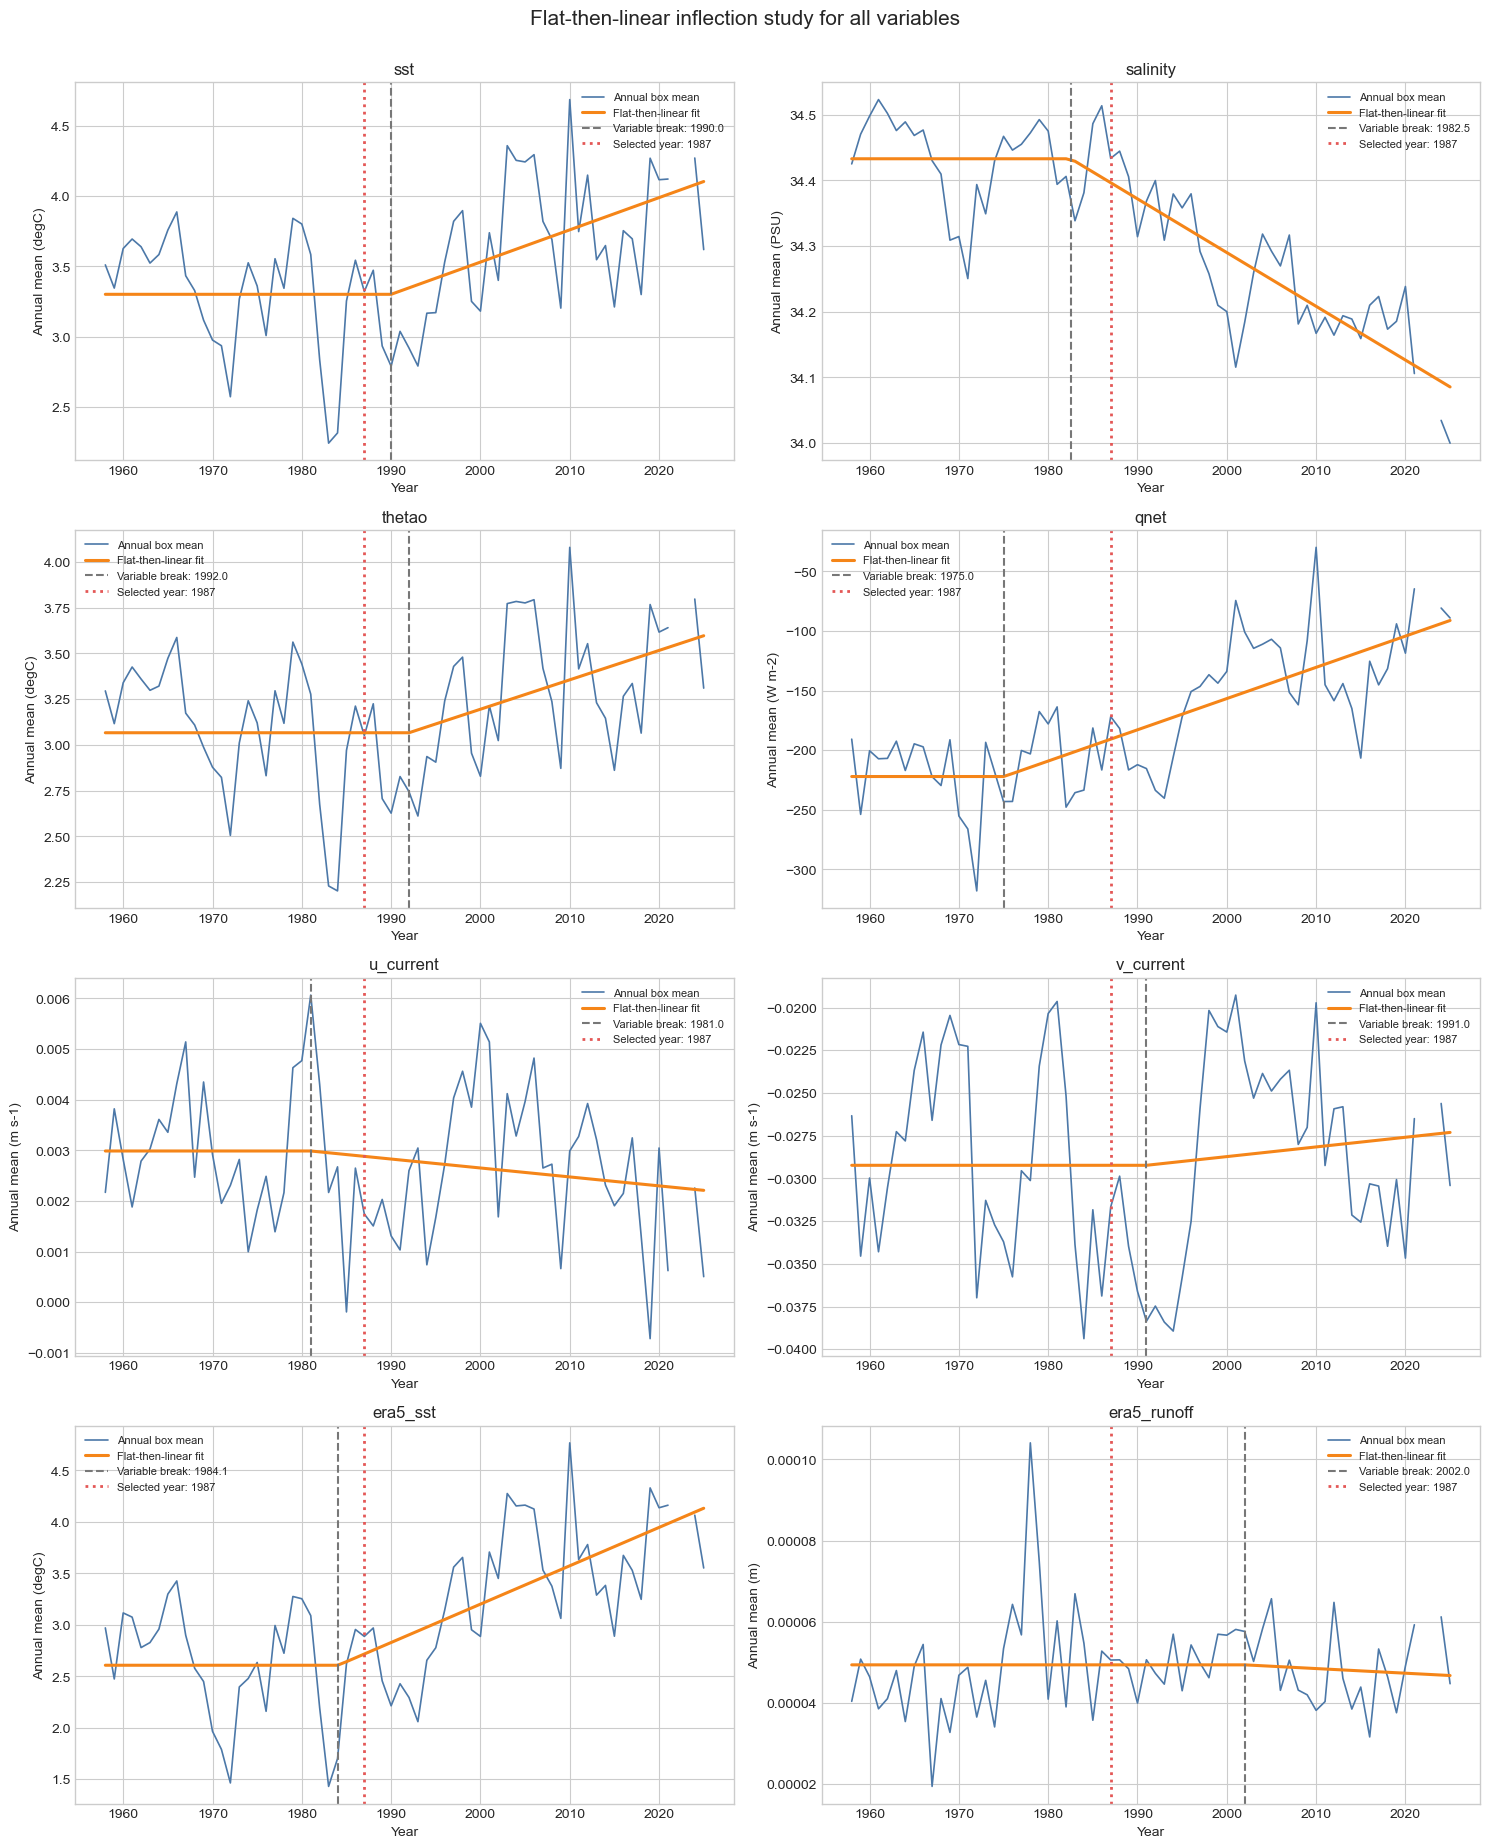

In [7]:
features = annual_box_mean.feature.values.astype(str).tolist()
ncols = 2
nrows = math.ceil(len(features) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4.6 * nrows), squeeze=False)
for ax, feature in zip(axes.ravel(), features):
    series = annual_box_mean.sel(feature=feature)
    ax.plot(series.year, series, color="#4c78a8", linewidth=1.2, label="Annual box mean")
    if feature in inflection_fits:
        fit = inflection_fits[feature]
        ax.plot(fit["years"], fit["fitted"], color="#f58518", linewidth=2.2,
                label="Flat-then-linear fit")
        ax.axvline(fit["break_year"], color="#777777", linestyle="--",
                   label=f"Variable break: {fit['break_year']:.1f}")
    else:
        ax.text(0.5, 0.5, inflection_summary.loc[feature, "status"],
                transform=ax.transAxes, ha="center", va="center", wrap=True)
    ax.axvline(SELECTED_INFLECTION_YEAR, color="#e45756", linestyle=":", linewidth=2,
               label=f"Selected year: {SELECTED_INFLECTION_YEAR}")
    unit = FEATURE_UNITS.get(feature, "")
    ax.set(title=feature, xlabel="Year", ylabel=f"Annual mean ({unit})" if unit else "Annual mean")
    ax.legend(frameon=False, fontsize=8)
for ax in axes.ravel()[len(features):]:
    ax.set_visible(False)
fig.suptitle("Flat-then-linear inflection study for all variables", fontsize=15, y=1.002)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "flat_linear_inflection_all_variables.png", dpi=190, bbox_inches="tight")
plt.show()

## 3. Statistical method

1. Spatial avg
2. Annual avg
3. Ordinary least-squares lin fitted using only annual spatial avgs before inflection year
4. $z = \frac{y_{observed}-y_{expected}}{\sqrt{\sigma^2 + Var(\hat{y})}}.$
5. overall_z_score = sum(z)/sqrt(n)

In [8]:
def pre_inflection_ols_zscores(annual, inflection_year, min_pre_years=3):
    if "year" not in annual.dims:
        raise ValueError("annual must include a 'year' dimension.")
    pre = annual.where(annual.year < inflection_year, drop=True).astype(np.float64)
    if pre.sizes.get("year", 0) < max(min_pre_years, 3):
        raise ValueError("Not enough pre-inflection years for OLS.")

    x_pre = xr.DataArray(
        pre.year.values.astype(float) - float(inflection_year),
        coords={"year": pre.year}, dims=("year",),
    )
    valid = np.isfinite(pre)
    n = valid.sum("year")
    x_bar = x_pre.where(valid).sum("year", skipna=True) / n
    y_bar = pre.where(valid).sum("year", skipna=True) / n
    x_centered = x_pre - x_bar
    y_centered = pre - y_bar
    sxx = (x_centered ** 2).where(valid).sum("year", skipna=True)
    sxy = (x_centered * y_centered).where(valid).sum("year", skipna=True)
    slope = sxy / sxx
    intercept = y_bar - slope * x_bar

    fitted_pre = intercept + slope * x_pre
    sse = ((pre - fitted_pre) ** 2).where(valid).sum("year", skipna=True)
    sst = ((pre - y_bar) ** 2).where(valid).sum("year", skipna=True)
    dof = n - 2
    residual_variance = sse / dof
    residual_std = np.sqrt(residual_variance)
    r_squared = 1 - sse / sst

    x_all = xr.DataArray(
        annual.year.values.astype(float) - float(inflection_year),
        coords={"year": annual.year}, dims=("year",),
    )
    expected = (intercept + slope * x_all).transpose(*annual.dims)
    fitted_mean_variance = (
        residual_variance * (1 / n + (x_all - x_bar) ** 2 / sxx)
    ).transpose(*annual.dims)
    predictive_se = np.sqrt(
        residual_variance + fitted_mean_variance
    ).transpose(*annual.dims)

    quality = (
        (n >= max(min_pre_years, 3))
        & np.isfinite(sxx) & (sxx > 0)
        & np.isfinite(residual_variance) & (residual_variance > 0)
    )
    distance = (annual - expected).where(quality)
    z_score = (distance / predictive_se).where(annual.year >= inflection_year)

    return xr.Dataset({
        "annual_spatial_mean": annual.astype(np.float32),
        "expected_from_pretrend": expected.astype(np.float32),
        "distance_from_fit": distance.astype(np.float32),
        "predictive_se": predictive_se.astype(np.float32),
        "z_score": z_score.astype(np.float32),
        "slope_per_year": slope.where(quality).astype(np.float32),
        "intercept_at_inflection": intercept.where(quality).astype(np.float32),
        "residual_std": residual_std.where(quality).astype(np.float32),
        "r_squared": r_squared.where(quality).astype(np.float32),
        "n_pre_years": n.astype(np.int16),
    })

box_statistics = pre_inflection_ols_zscores(
    annual_box_mean, SELECTED_INFLECTION_YEAR, MIN_PRE_INFLECTION_YEARS
)

ANNUAL_SPATIAL_MEANS_PATH = OUTPUT_DIR / "annual_spatial_means_by_variable.csv"
YEARLY_ZSCORE_PATH = OUTPUT_DIR / f"post_inflection_annual_zscores_{SELECTED_INFLECTION_YEAR}.csv"
FIT_PARAMETERS_PATH = OUTPUT_DIR / f"pre_inflection_fit_parameters_{SELECTED_INFLECTION_YEAR}.csv"
OVERALL_ZSCORE_PATH = OUTPUT_DIR / f"overall_zscore_by_variable_{SELECTED_INFLECTION_YEAR}.csv"

annual_spatial_means = annual_box_mean.transpose("year", "feature").to_pandas()
annual_spatial_means.to_csv(ANNUAL_SPATIAL_MEANS_PATH)

yearly_value_names = (
    "annual_spatial_mean", "expected_from_pretrend",
    "distance_from_fit", "predictive_se", "z_score",
)
yearly_statistics = xr.Dataset({
    name: box_statistics[name]
    for name in yearly_value_names
}).to_dataframe().reset_index()
yearly_statistics = yearly_statistics[["year", "feature", *yearly_value_names]]
yearly_statistics = yearly_statistics[
    yearly_statistics["year"] >= SELECTED_INFLECTION_YEAR
].sort_values(["feature", "year"]).reset_index(drop=True)
yearly_statistics.to_csv(YEARLY_ZSCORE_PATH, index=False)

fit_parameter_names = (
    "slope_per_year", "intercept_at_inflection", "residual_std",
    "r_squared", "n_pre_years",
)
fit_parameters = xr.Dataset({
    name: box_statistics[name]
    for name in fit_parameter_names
}).to_dataframe().reset_index()
fit_parameters = fit_parameters[["feature", *fit_parameter_names]].set_index("feature")
fit_parameters.to_csv(FIT_PARAMETERS_PATH)

overall_rows = []
for feature, feature_df in yearly_statistics.groupby("feature", sort=False):
    z_values = feature_df["z_score"].dropna().to_numpy(dtype=float)
    n_post = int(z_values.size)
    overall_rows.append({
        "feature": feature,
        "n_post_inflection_years": n_post,
        #"signed_z_sum": float(z_values.sum()) if n_post else np.nan,
        "overall_z_score": float(z_values.sum() / np.sqrt(n_post)) if n_post else np.nan,
        "mean_z_score": float(z_values.mean()) if n_post else np.nan,
        #"mean_absolute_z_score": float(np.mean(np.abs(z_values))) if n_post else np.nan,
        "rms_z_score": float(np.sqrt(np.mean(z_values ** 2))) if n_post else np.nan,
    })
overall_zscores = pd.DataFrame(overall_rows).set_index("feature")
overall_zscores.to_csv(OVERALL_ZSCORE_PATH)

print("Saved annual spatial means:", ANNUAL_SPATIAL_MEANS_PATH)
print("Saved yearly post-inflection z-scores:", YEARLY_ZSCORE_PATH)
print("Saved pre-inflection fit parameters:", FIT_PARAMETERS_PATH)
print("Saved overall z-score summary:", OVERALL_ZSCORE_PATH)
display(yearly_statistics.head())
display(overall_zscores)

Saved annual spatial means: C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\Processed\combined_box_study_55N_64N_60W_50W_0p5x0p5deg\annual_spatial_means_by_variable.csv
Saved yearly post-inflection z-scores: C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\Processed\combined_box_study_55N_64N_60W_50W_0p5x0p5deg\post_inflection_annual_zscores_1987.csv
Saved pre-inflection fit parameters: C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\Processed\combined_box_study_55N_64N_60W_50W_0p5x0p5deg\pre_inflection_fit_parameters_1987.csv
Saved overall z-score summary: C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\Processed\combined_box_study_55N_64N_60W_50W_0p5x0p5deg\overall_zscore_by_variable_1987.csv


,year,feature,annual_spatial_mean,expected_from_pretrend,distance_from_fit,predictive_se,z_score
0,1987,era5_runoff,0.000051,0.000058,-0.000008,0.000016,-0.489758
1,1988,era5_runoff,0.000051,0.000059,-0.000008,0.000016,-0.523767
2,1989,era5_runoff,0.000048,0.000060,-0.000011,0.000016,-0.695486
3,1990,era5_runoff,0.000040,0.000060,-0.000020,0.000016,-1.245663
4,1991,era5_runoff,0.000051,0.000061,-0.000010,0.000016,-0.629229


,n_post_inflection_years,overall_z_score,mean_z_score,rms_z_score
feature,,,,
era5_runoff,37,-6.505607,-1.069515,1.178806
era5_sst,37,11.882963,1.953547,2.226695
qnet,37,9.445967,1.552907,1.877369
salinity,37,-9.588108,-1.576275,1.849480
sst,37,10.865650,1.786302,2.117001
thetao,37,10.856621,1.784817,2.120159
u_current,37,0.173455,0.028516,0.818837
v_current,37,2.663584,0.437891,0.963054


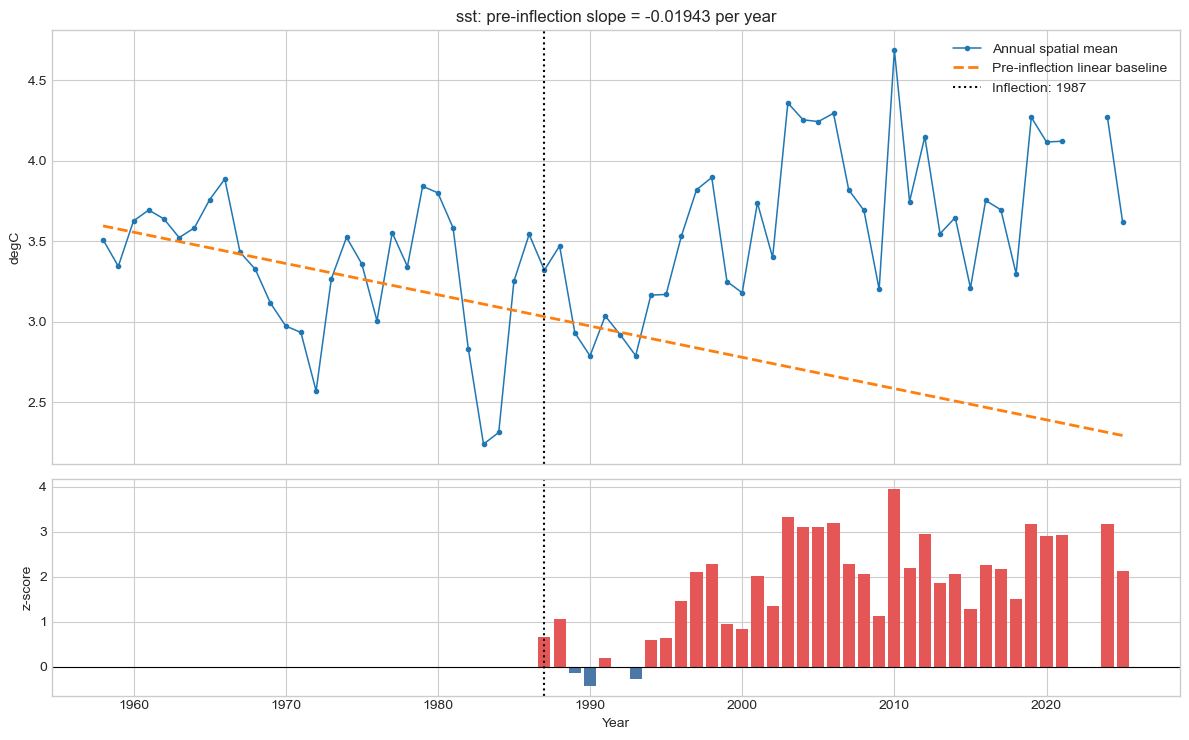

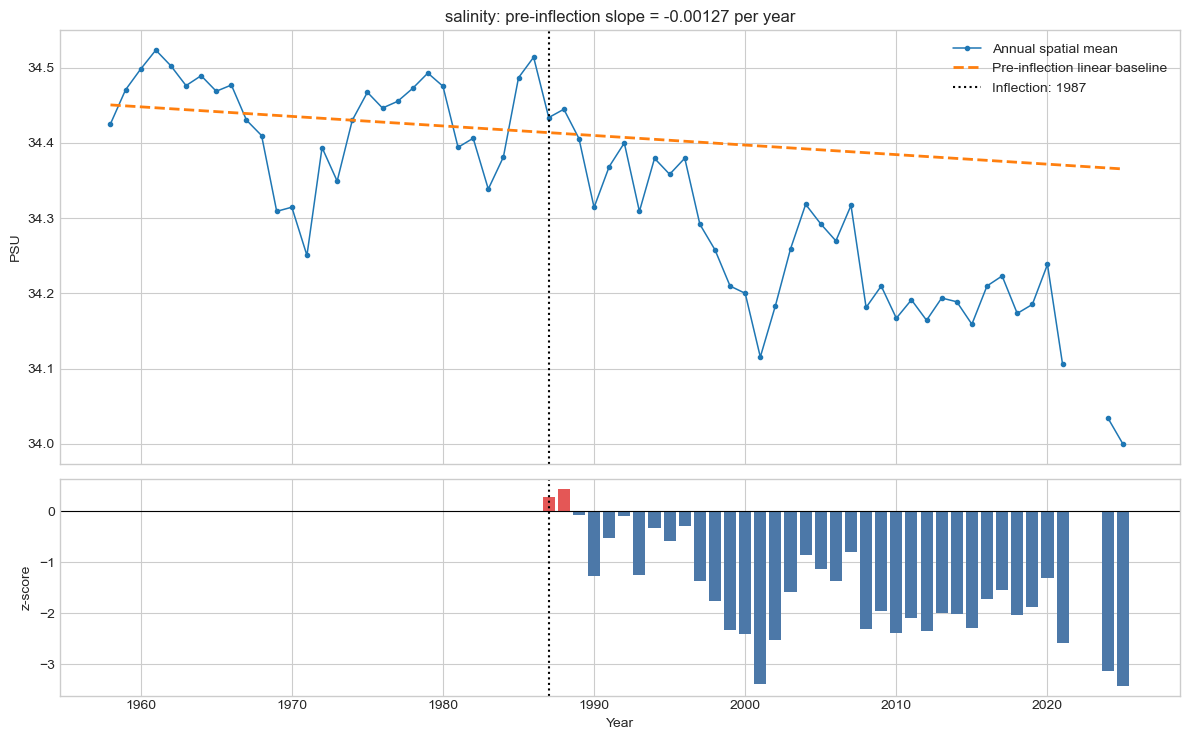

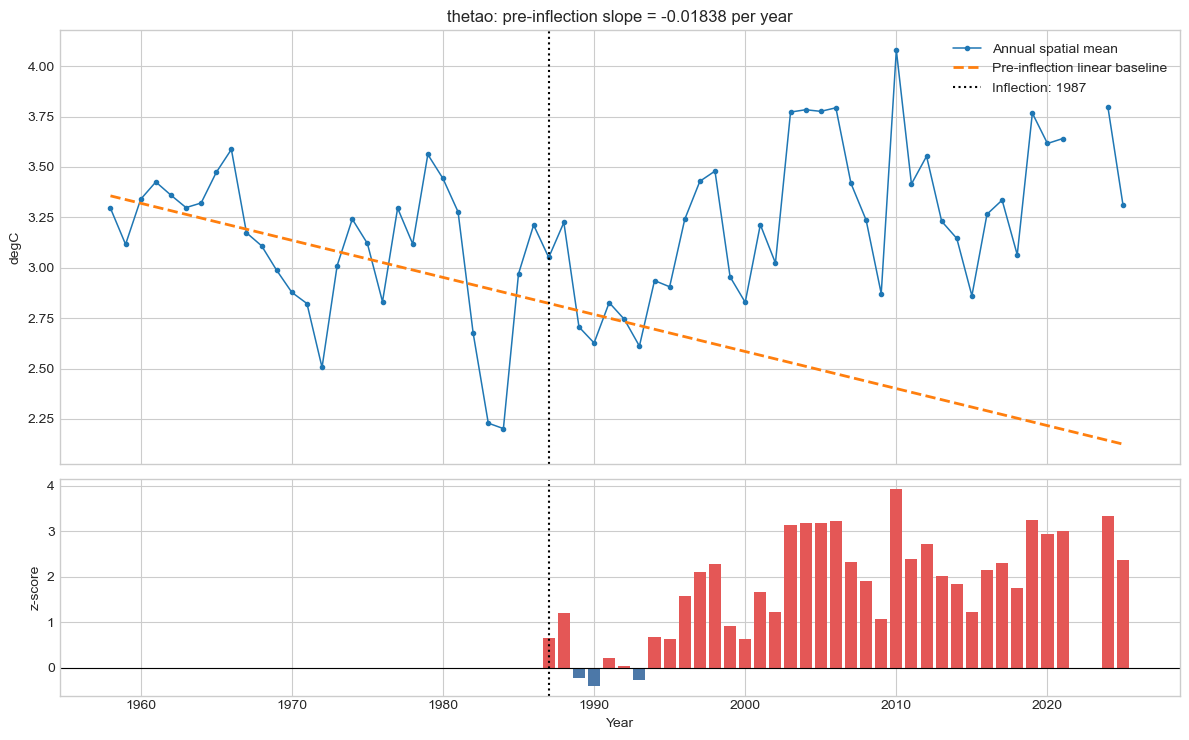

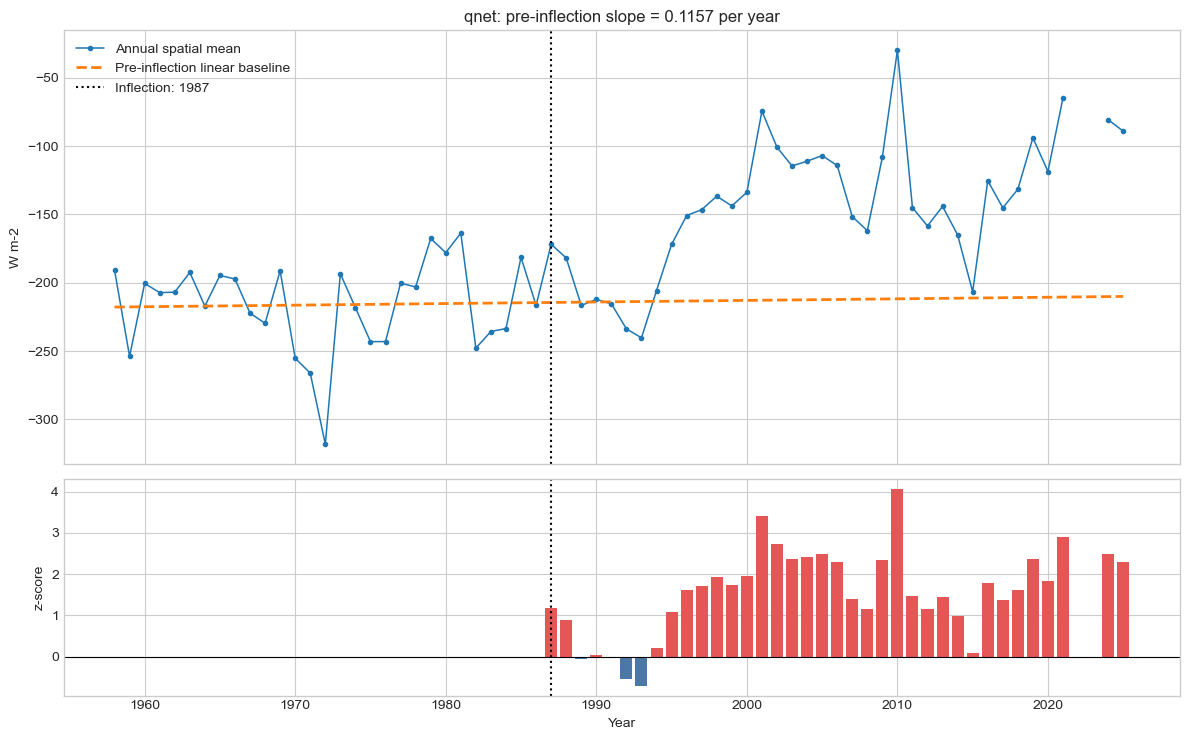

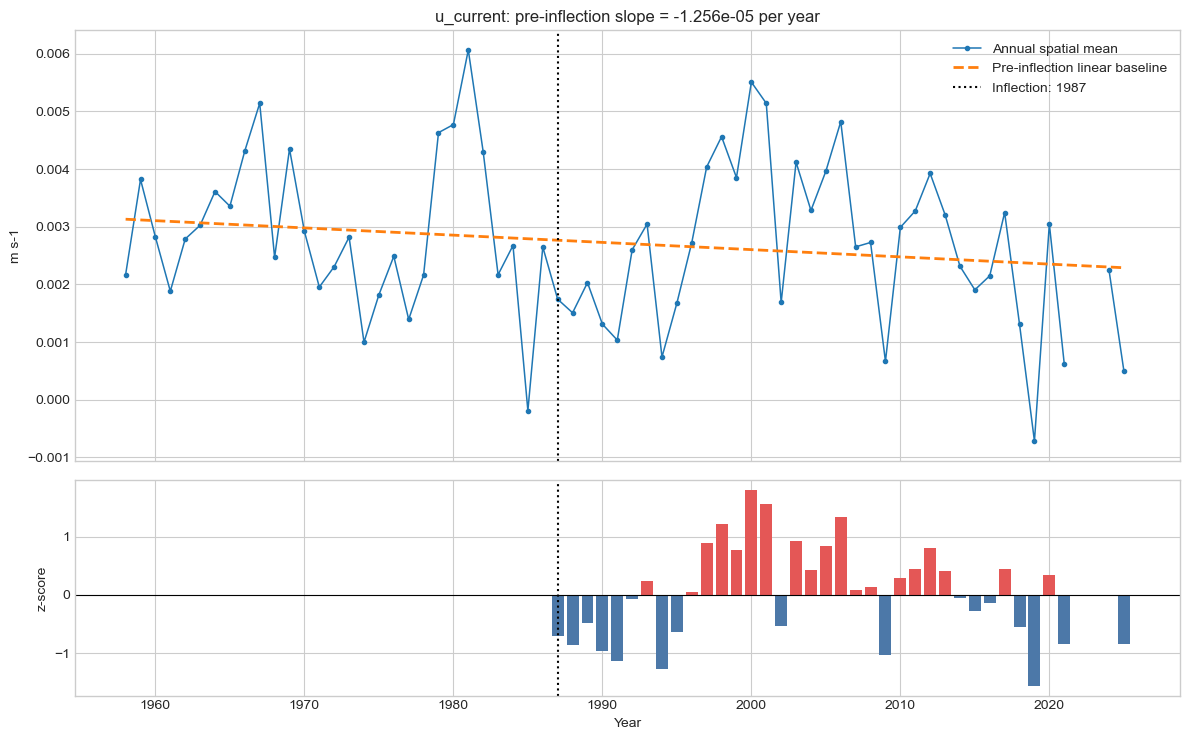

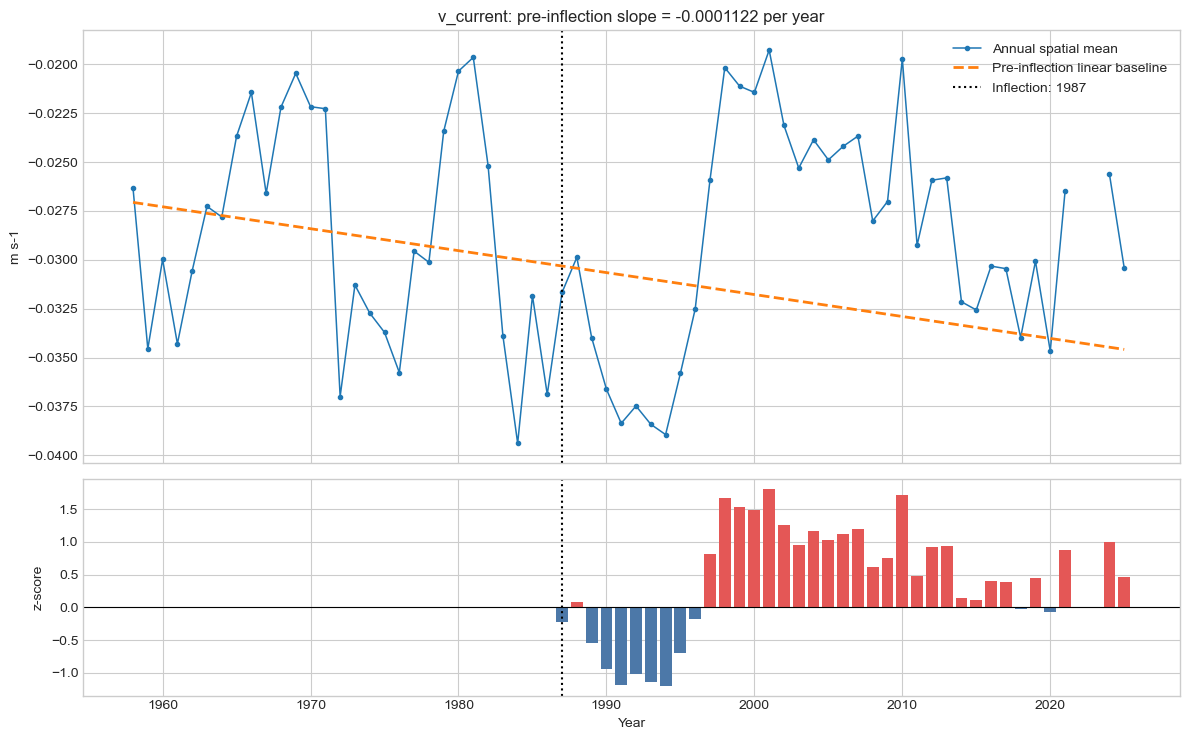

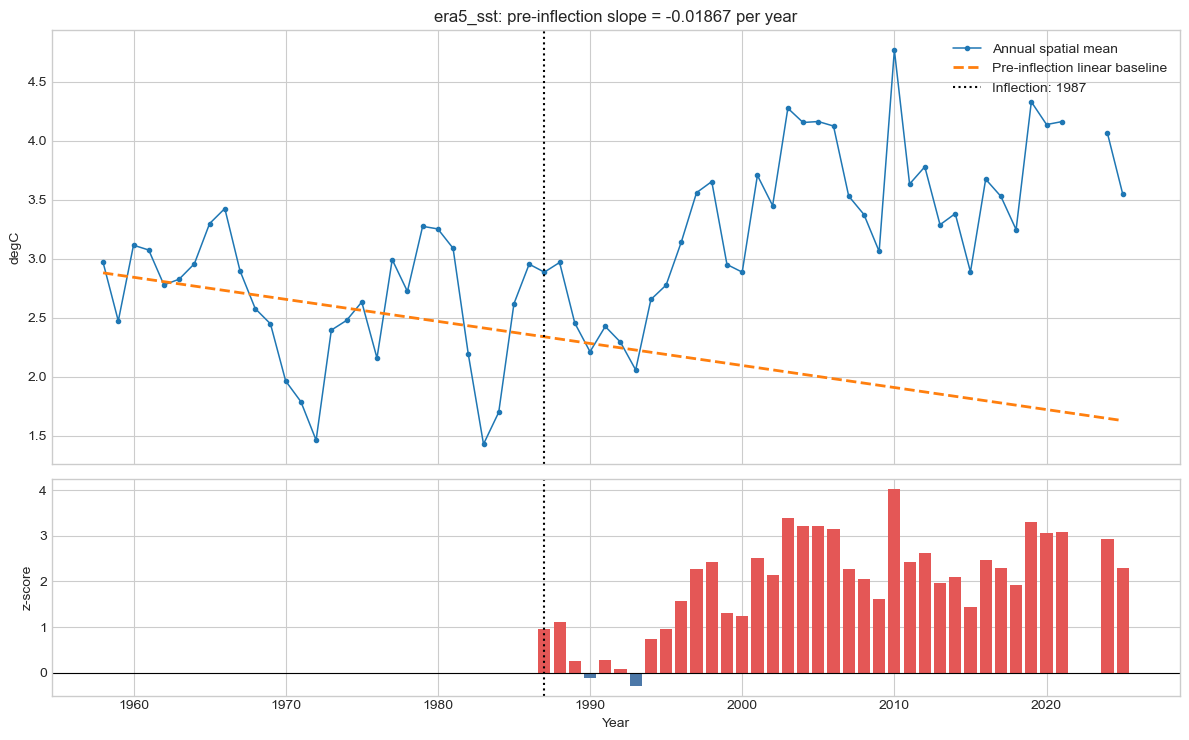

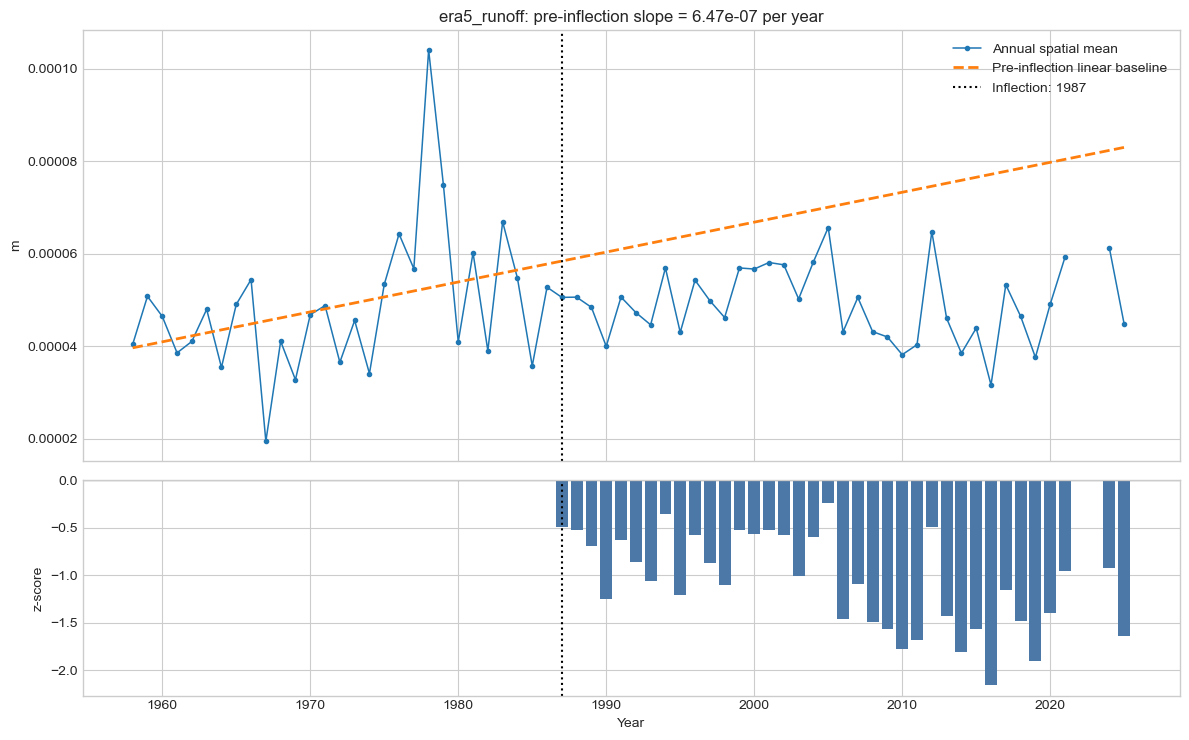

In [9]:
for feature in annual_box_mean.feature.values.astype(str):
    observed = box_statistics["annual_spatial_mean"].sel(feature=feature)
    expected = box_statistics["expected_from_pretrend"].sel(feature=feature)
    z = box_statistics["z_score"].sel(feature=feature)
    slope = float(box_statistics["slope_per_year"].sel(feature=feature))

    fig, axes = plt.subplots(2, 1, figsize=(12, 7.5), sharex=True,
                             gridspec_kw={"height_ratios": [2, 1]})
    axes[0].plot(
        observed.year, observed, "o-", ms=3, lw=1.1,
        label="Annual spatial mean",
    )
    axes[0].plot(expected.year, expected, "--", lw=2, label="Pre-inflection linear baseline")
    axes[0].axvline(SELECTED_INFLECTION_YEAR, color="black", ls=":",
                    label=f"Inflection: {SELECTED_INFLECTION_YEAR}")
    axes[0].set(ylabel=FEATURE_UNITS.get(feature, feature),
                title=f"{feature}: pre-inflection slope = {slope:.4g} per year")
    axes[0].legend(frameon=False)

    axes[1].bar(z.year, z, width=0.8, color=np.where(z.fillna(0) >= 0, "#e45756", "#4c78a8"))
    axes[1].axhline(0, color="black", linewidth=0.8)
    axes[1].axvline(SELECTED_INFLECTION_YEAR, color="black", ls=":")
    axes[1].set(xlabel="Year", ylabel="z-score")
    fig.tight_layout()
    safe = re.sub(r"[^A-Za-z0-9_-]+", "_", feature)
    fig.savefig(OUTPUT_DIR / f"statistical_method_{safe}.png", dpi=180, bbox_inches="tight")
    plt.show()

## 4. Adapted Shreya recursive ConvLSTM

In [10]:
try:
    import tensorflow as tf
    from tensorflow.keras import Sequential
    from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
    from tensorflow.keras.layers import Input, ConvLSTM2D, BatchNormalization, Conv2D
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
except ImportError as exc:
    raise ImportError(
        "The Adapted Shreya section requires tensorflow and scikit-learn. "
        "Install the packages shown in Section 0, restart the kernel, and rerun."
    ) from exc

tf.get_logger().setLevel("ERROR")
tf.random.set_seed(SEED)
print("TensorFlow:", tf.__version__)
print("Visible GPUs:", tf.config.list_physical_devices("GPU"))

FORECAST_START = pd.Timestamp(SELECTED_INFLECTION_YEAR, 1, 1)
VALIDATION_START = FORECAST_START - pd.DateOffset(years=VALIDATION_YEARS)
observed_times = pd.DatetimeIndex(pd.to_datetime(combined_monthly.time.values))
FORECAST_END = (
    observed_times.max().to_period("M").to_timestamp()
    if CONVLSTM_FORECAST_END is None
    else pd.Timestamp(CONVLSTM_FORECAST_END).to_period("M").to_timestamp()
)
if FORECAST_END < FORECAST_START:
    raise ValueError("CONVLSTM_FORECAST_END must not precede the selected inflection year.")

CONVLSTM_DIR = OUTPUT_DIR / f"adapted_shreya_{SELECTED_INFLECTION_YEAR}"
CONVLSTM_DIR.mkdir(parents=True, exist_ok=True)
MODEL_PATH = CONVLSTM_DIR / "best_adapted_shreya_one_step.keras"
SCALER_PATH = CONVLSTM_DIR / "training_only_scaler.pkl"
HISTORY_PATH = CONVLSTM_DIR / "training_history.json"
PREDICTION_PATH = CONVLSTM_DIR / "adapted_shreya_predictions.nc"

print("Training targets before:", VALIDATION_START.date())
print("Validation:", VALIDATION_START.date(), "to", (FORECAST_START - pd.DateOffset(months=1)).date())
print("Recursive forecast:", FORECAST_START.date(), "to", FORECAST_END.date())

TensorFlow: 2.21.0
Visible GPUs: []
Training targets before: 1982-01-01
Validation: 1982-01-01 to 1986-12-01
Recursive forecast: 1987-01-01 to 2025-12-01


In [11]:
# Select model-usable variables, then impute and scale using training data only.
times = pd.DatetimeIndex(pd.to_datetime(combined_monthly.time.values))
train_reference_mask = times < VALIDATION_START
if train_reference_mask.sum() < LOOKBACK + 3:
    raise ValueError("Too little data precedes the ConvLSTM validation period.")

quality_rows = []
convlstm_features = []
for feature in combined_monthly.feature.values.astype(str):
    values = combined_monthly.sel(feature=feature).values
    finite_fraction = float(np.isfinite(values).mean())
    training_std = float(np.nanstd(values[train_reference_mask]))
    keep = finite_fraction > 0 and np.isfinite(training_std) and training_std > 1e-8
    quality_rows.append({
        "feature": feature, "finite_fraction": finite_fraction,
        "training_std": training_std, "retained": keep,
    })
    if keep:
        convlstm_features.append(feature)
convlstm_quality = pd.DataFrame(quality_rows)
display(convlstm_quality)
if not convlstm_features:
    raise ValueError("No non-empty, non-constant variables remain for ConvLSTM.")

convlstm_monthly = combined_monthly.sel(feature=convlstm_features)
raw_data = convlstm_monthly.transpose("time", "lat", "lon", "feature").values.astype(np.float32)
n_time, n_lat, n_lon, n_features = raw_data.shape
training_reference = raw_data[train_reference_mask]
training_times = times[train_reference_mask]

month_climatology = np.full((12, n_lat, n_lon, n_features), np.nan, np.float32)
for month in range(1, 13):
    month_climatology[month - 1] = np.nanmean(
        training_reference[training_times.month == month], axis=0
    )
cell_mean = np.nanmean(training_reference, axis=0)
feature_median = np.array(
    [np.nanmedian(training_reference[..., index]) for index in range(n_features)],
    dtype=np.float32,
)

data_filled = raw_data.copy()
for index, timestamp in enumerate(times):
    missing = ~np.isfinite(data_filled[index])
    if missing.any():
        data_filled[index][missing] = month_climatology[timestamp.month - 1][missing]
    missing = ~np.isfinite(data_filled[index])
    if missing.any():
        data_filled[index][missing] = cell_mean[missing]
    missing = ~np.isfinite(data_filled[index])
    if missing.any():
        fallback = np.broadcast_to(feature_median, data_filled[index].shape)
        data_filled[index][missing] = fallback[missing]
if not np.isfinite(data_filled).all():
    raise ValueError("Non-finite values remain after training-only imputation.")

feature_mean = data_filled[train_reference_mask].mean((0, 1, 2)).astype(np.float32)
feature_std = data_filled[train_reference_mask].std((0, 1, 2)).astype(np.float32)
feature_std = np.where(feature_std < 1e-8, 1.0, feature_std).astype(np.float32)
data_scaled = ((data_filled - feature_mean) / feature_std).astype(np.float32)

def inverse_scale(values):
    return values * feature_std + feature_mean

with open(SCALER_PATH, "wb") as handle:
    pickle.dump({
        "features": convlstm_features, "mean": feature_mean, "std": feature_std,
        "month_climatology": month_climatology, "cell_mean": cell_mean,
        "feature_median": feature_median,
        "fit_end": str(times[train_reference_mask][-1].date()),
    }, handle)

print("ConvLSTM shape (time, lat, lon, feature):", raw_data.shape)
print("ConvLSTM features:", convlstm_features)

,feature,finite_fraction,training_std,retained
0,sst,1.000000,2.224385,True
1,salinity,1.000000,0.856772,True
2,thetao,1.000000,1.832867,True
3,qnet,1.000000,337.735718,True
4,u_current,1.000000,0.098859,True
5,v_current,1.000000,0.135365,True
6,era5_sst,0.967419,2.557288,True
7,era5_runoff,1.000000,0.000517,True


ConvLSTM shape (time, lat, lon, feature): (797, 19, 21, 8)
ConvLSTM features: ['sst', 'salinity', 'thetao', 'qnet', 'u_current', 'v_current', 'era5_sst', 'era5_runoff']


In [12]:
def is_consecutive(months):
    months = pd.DatetimeIndex(months)
    return len(months) > 0 and months.equals(
        pd.date_range(months[0], periods=len(months), freq="MS")
    )

def make_one_step_samples(values, value_times):
    X, y, targets = [], [], []
    for target_index in range(LOOKBACK, len(value_times)):
        window_times = value_times[target_index - LOOKBACK:target_index + 1]
        if is_consecutive(window_times):
            X.append(values[target_index - LOOKBACK:target_index])
            y.append(values[target_index])
            targets.append(value_times[target_index])
    return (
        np.asarray(X, dtype=np.float32),
        np.asarray(y, dtype=np.float32),
        pd.DatetimeIndex(targets),
    )

X, y, target_times = make_one_step_samples(data_scaled, times)
train_samples = target_times < VALIDATION_START
validation_samples = (
    (target_times >= VALIDATION_START) & (target_times < FORECAST_START)
)
if train_samples.sum() == 0 or validation_samples.sum() == 0:
    raise ValueError("The chronological ConvLSTM training or validation split is empty.")
print("Training samples:", X[train_samples].shape)
print("Validation samples:", X[validation_samples].shape)

def build_adapted_shreya_model():
    first, second, third = CONVLSTM_FILTERS
    model = Sequential([
        Input(shape=(LOOKBACK, n_lat, n_lon, n_features)),
        ConvLSTM2D(first, (3, 3), padding="same", return_sequences=True),
        BatchNormalization(),
        ConvLSTM2D(second, (3, 3), padding="same", return_sequences=True),
        BatchNormalization(),
        ConvLSTM2D(third, (3, 3), padding="same", return_sequences=False),
        BatchNormalization(),
        Conv2D(n_features, (3, 3), padding="same", activation="linear"),
    ], name="Adapted_Shreya_one_step_ConvLSTM")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(CONVLSTM_LEARNING_RATE),
        loss="mse", metrics=["mae"],
    )
    return model

adapted_shreya_model = build_adapted_shreya_model()
adapted_shreya_model.summary()

Training samples: (263, 12, 19, 21, 8)
Validation samples: (60, 12, 19, 21, 8)


Model: "Adapted_Shreya_one_step_ConvLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv_lstm2d (ConvLSTM2D)             │ (None, 12, 19, 21, 32)      │          46,208 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 12, 19, 21, 32)      │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_lstm2d_1 (ConvLSTM2D)           │ (None, 12, 19, 21, 32)      │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 12, 19, 21, 32)      │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_lstm2d_2 (ConvLSTM2D)           │ (None, 19, 21, 16)          │          27,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 19, 21, 16)          │              64 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 19, 21, 8)           │           1,160 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 149,256 (583.03 KB)

 Trainable params: 149,096 (582.41 KB)

 Non-trainable params: 160 (640.00 B)

In [13]:
def training_callbacks(model_path):
    return [
        ModelCheckpoint(model_path, monitor="val_loss", save_best_only=True, verbose=1),
        ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6, verbose=1
        ),
        EarlyStopping(
            monitor="val_loss", patience=8, restore_best_weights=True, verbose=1
        ),
    ]

if TRAIN_CONVLSTM:
    history = adapted_shreya_model.fit(
        X[train_samples], y[train_samples],
        validation_data=(X[validation_samples], y[validation_samples]),
        epochs=CONVLSTM_EPOCHS,
        batch_size=CONVLSTM_BATCH_SIZE,
        shuffle=False,
        callbacks=training_callbacks(MODEL_PATH),
        verbose=1,
    )
    HISTORY_PATH.write_text(json.dumps(
        {key: [float(value) for value in values]
         for key, values in history.history.items()}, indent=2
    ))
elif not MODEL_PATH.exists():
    raise FileNotFoundError(
        f"TRAIN_CONVLSTM=False but the compatible model is missing: {MODEL_PATH}"
    )

adapted_shreya_model = tf.keras.models.load_model(MODEL_PATH)
print("Loaded best validation model:", MODEL_PATH)

Epoch 1/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 749ms/step - loss: 0.8745 - mae: 0.6524
Epoch 1: val_loss improved from None to 0.67650, saving model to C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\Processed\combined_box_study_55N_64N_60W_50W_0p5x0p5deg\adapted_shreya_1987\best_adapted_shreya_one_step.keras

Epoch 1: finished saving model to C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\Processed\combined_box_study_55N_64N_60W_50W_0p5x0p5deg\adapted_shreya_1987\best_adapted_shreya_one_step.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 209s 1s/step - loss: 0.6216 - mae: 0.5372 - val_loss: 0.6765 - val_mae: 0.5484 - learning_rate: 0.0010
Epoch 2/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 799ms/step - loss: 0.4003 - mae: 0.4331
Epoch 2: val_loss improved from 0.67650 to 0.57929, saving model to C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\Processed\combined_box_study_55N_64N_60W_50W_0p5x0p5deg\adapted_shreya_1987\best_adapted_shreya_one_step.keras

Epoch 2: finished saving model to C:\Users\itsna\OneDriv

In [14]:
time_to_index = {timestamp: index for index, timestamp in enumerate(times)}

def observed_window_before(target_time):
    preceding = pd.date_range(
        target_time - pd.DateOffset(months=LOOKBACK), periods=LOOKBACK, freq="MS"
    )
    missing = preceding.difference(times)
    if len(missing):
        raise ValueError(
            "Missing month(s) in the required observed initialization window: "
            + ", ".join(timestamp.strftime("%Y-%m") for timestamp in missing)
        )
    return np.stack([data_scaled[time_to_index[timestamp]] for timestamp in preceding])

forecast_times = pd.date_range(FORECAST_START, FORECAST_END, freq="MS")
recursive_window = observed_window_before(FORECAST_START)
adapted_shreya_scaled = np.empty(
    (len(forecast_times), n_lat, n_lon, n_features), dtype=np.float32
)
for index, target_time in enumerate(forecast_times):
    prediction = adapted_shreya_model.predict(recursive_window[None, ...], verbose=0)[0]
    adapted_shreya_scaled[index] = prediction
    recursive_window = np.concatenate(
        [recursive_window[1:], prediction[None, ...]], axis=0
    )
    if index == 0 or (index + 1) % 12 == 0 or index + 1 == len(forecast_times):
        print(f"Predicted {index + 1}/{len(forecast_times)}: {target_time:%Y-%m}")

adapted_shreya_prediction = inverse_scale(adapted_shreya_scaled).astype(np.float32)
actual = np.full_like(adapted_shreya_prediction, np.nan)
for index, timestamp in enumerate(forecast_times):
    if timestamp in time_to_index:
        actual[index] = raw_data[time_to_index[timestamp]]

forecast_ds = xr.Dataset(
    data_vars={
        "actual": (
            ("time", "feature", "lat", "lon"),
            actual.transpose(0, 3, 1, 2),
        ),
        "adapted_shreya_prediction": (
            ("time", "feature", "lat", "lon"),
            adapted_shreya_prediction.transpose(0, 3, 1, 2),
        ),
    },
    coords={
        "time": forecast_times,
        "feature": convlstm_features,
        "lat": convlstm_monthly.lat.values,
        "lon": convlstm_monthly.lon.values,
    },
    attrs={
        "description": "Adapted Shreya one-step recursive ConvLSTM forecast",
        "selected_inflection_year": SELECTED_INFLECTION_YEAR,
        "training_targets_before": str(VALIDATION_START.date()),
        "validation_start": str(VALIDATION_START.date()),
        "forecast_start": str(FORECAST_START.date()),
    },
)
forecast_ds.to_netcdf(
    PREDICTION_PATH, engine=NETCDF_ENGINE,
    encoding={
        name: {"zlib": True, "complevel": 4, "shuffle": True, "dtype": "float32"}
        for name in forecast_ds.data_vars
    },
)
print("Saved Adapted Shreya predictions:", PREDICTION_PATH)

Predicted 1/468: 1987-01
Predicted 12/468: 1987-12
Predicted 24/468: 1988-12
Predicted 36/468: 1989-12
Predicted 48/468: 1990-12
Predicted 60/468: 1991-12
Predicted 72/468: 1992-12
Predicted 84/468: 1993-12
Predicted 96/468: 1994-12
Predicted 108/468: 1995-12
Predicted 120/468: 1996-12
Predicted 132/468: 1997-12
Predicted 144/468: 1998-12
Predicted 156/468: 1999-12
Predicted 168/468: 2000-12
Predicted 180/468: 2001-12
Predicted 192/468: 2002-12
Predicted 204/468: 2003-12
Predicted 216/468: 2004-12
Predicted 228/468: 2005-12
Predicted 240/468: 2006-12
Predicted 252/468: 2007-12
Predicted 264/468: 2008-12
Predicted 276/468: 2009-12
Predicted 288/468: 2010-12
Predicted 300/468: 2011-12
Predicted 312/468: 2012-12
Predicted 324/468: 2013-12
Predicted 336/468: 2014-12
Predicted 348/468: 2015-12
Predicted 360/468: 2016-12
Predicted 372/468: 2017-12
Predicted 384/468: 2018-12
Predicted 396/468: 2019-12
Predicted 408/468: 2020-12
Predicted 420/468: 2021-12
Predicted 432/468: 2022-12
Predicted 4

In [15]:
model_lat_weights = xr.DataArray(
    np.cos(np.deg2rad(forecast_ds.lat.values)),
    coords={"lat": forecast_ds.lat}, dims=("lat",),
)
actual_box = forecast_ds["actual"].weighted(model_lat_weights).mean(("lat", "lon"), skipna=True)
predicted_box = forecast_ds["adapted_shreya_prediction"].weighted(model_lat_weights).mean(
    ("lat", "lon"), skipna=True
)

metric_rows = []
for feature in convlstm_features:
    observed = actual_box.sel(feature=feature).values
    predicted = predicted_box.sel(feature=feature).values
    valid = np.isfinite(observed) & np.isfinite(predicted)
    if valid.sum() == 0:
        metric_rows.append({"feature": feature, "n_months": 0})
        continue
    metric_rows.append({
        "feature": feature,
        "comparison_start": forecast_times[valid][0],
        "comparison_end": forecast_times[valid][-1],
        "n_months": int(valid.sum()),
        "MAE": mean_absolute_error(observed[valid], predicted[valid]),
        "RMSE": np.sqrt(mean_squared_error(observed[valid], predicted[valid])),
        "R2": r2_score(observed[valid], predicted[valid]) if valid.sum() >= 2 else np.nan,
        "bias": float(np.mean(predicted[valid] - observed[valid])),
    })
adapted_shreya_metrics = pd.DataFrame(metric_rows).set_index("feature")
adapted_shreya_metrics.to_csv(CONVLSTM_DIR / "box_mean_metrics_all_variables.csv")
display(adapted_shreya_metrics)

,comparison_start,comparison_end,n_months,MAE,RMSE,R2,bias
feature,,,,,,,
sst,1987-01-01,2025-12-01,450,2.014594,2.660975,-0.606972,-1.905412
salinity,1987-01-01,2025-12-01,450,1.236790,1.475280,-42.665600,-1.221695
thetao,1987-01-01,2025-12-01,450,2.062715,2.533783,-1.982179,-1.991409
qnet,1987-01-01,2025-12-01,450,189.651414,257.293637,-0.433722,180.095402
u_current,1987-01-01,2025-12-01,450,0.058233,0.068241,-289.549205,0.057994
v_current,1987-01-01,2025-12-01,450,0.056536,0.065872,-53.388222,-0.055570
era5_sst,1987-01-01,2025-12-01,450,1.866612,2.535604,-0.204070,-1.687467
era5_runoff,1987-01-01,2025-12-01,450,0.000087,0.000108,-3.585022,0.000045


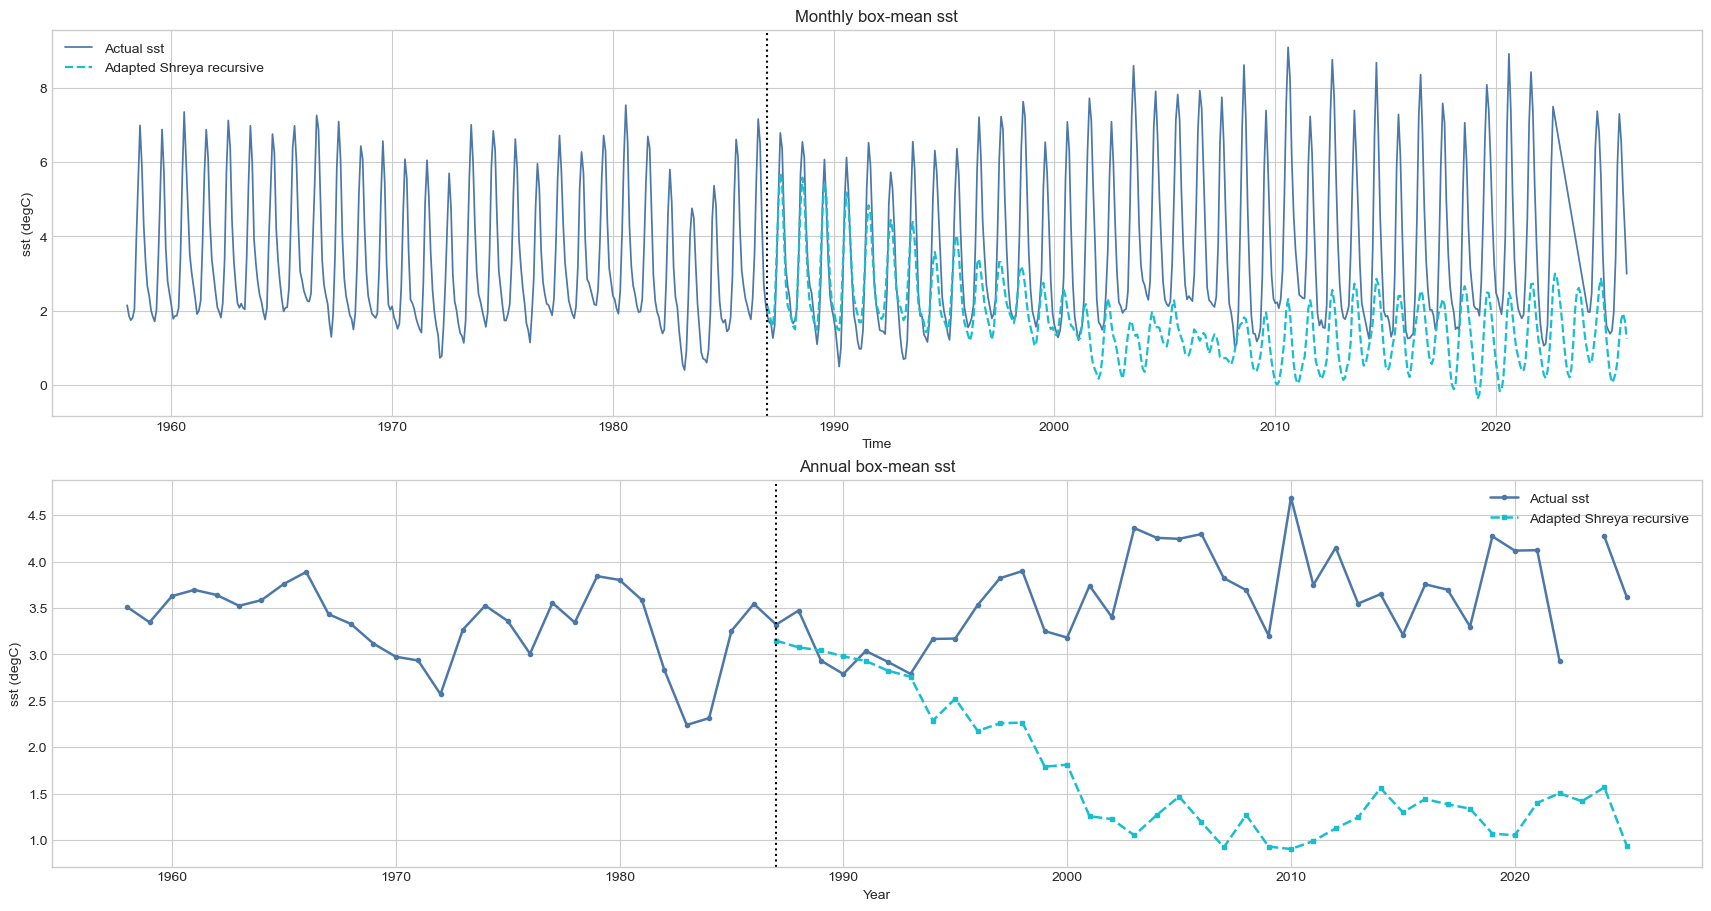

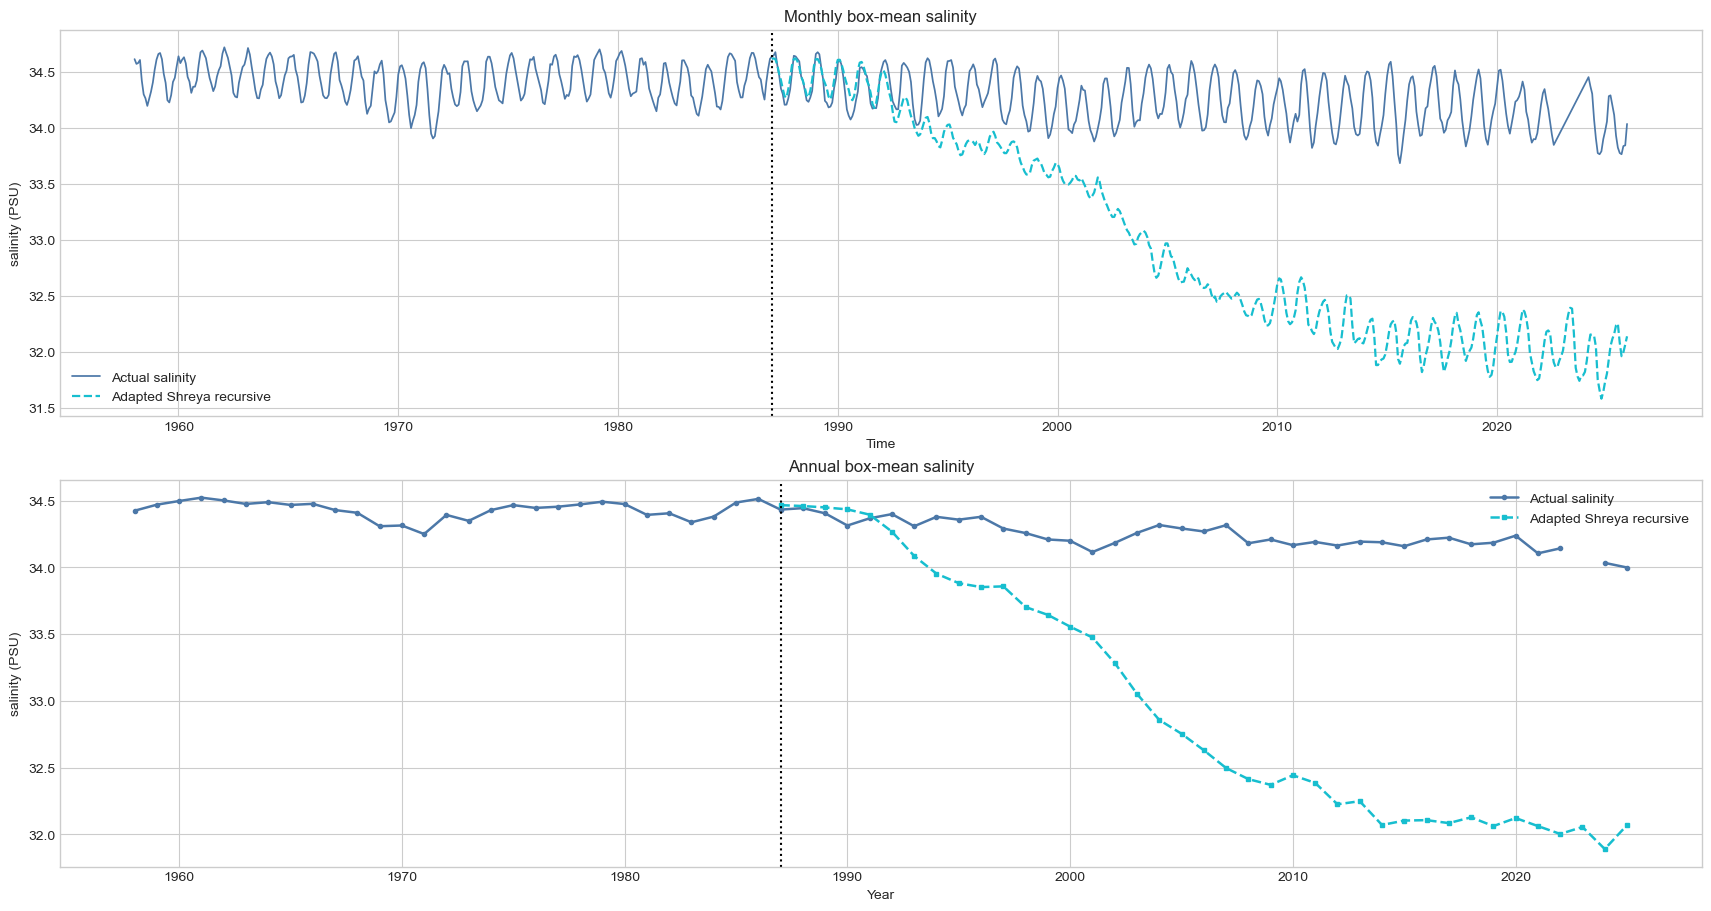

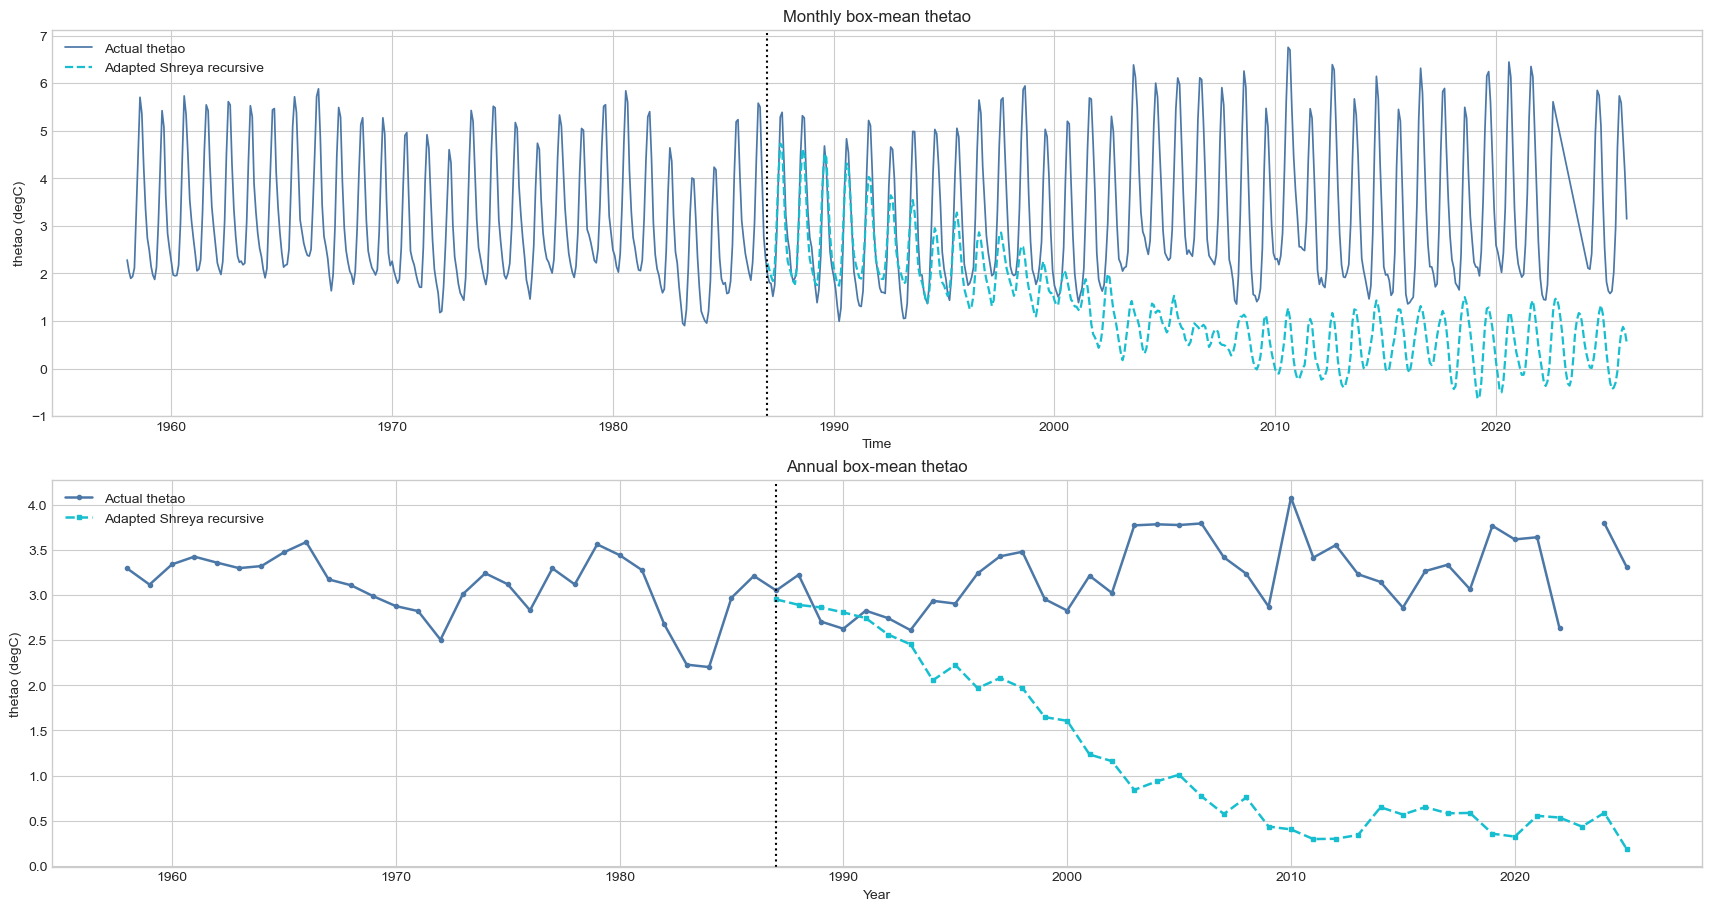

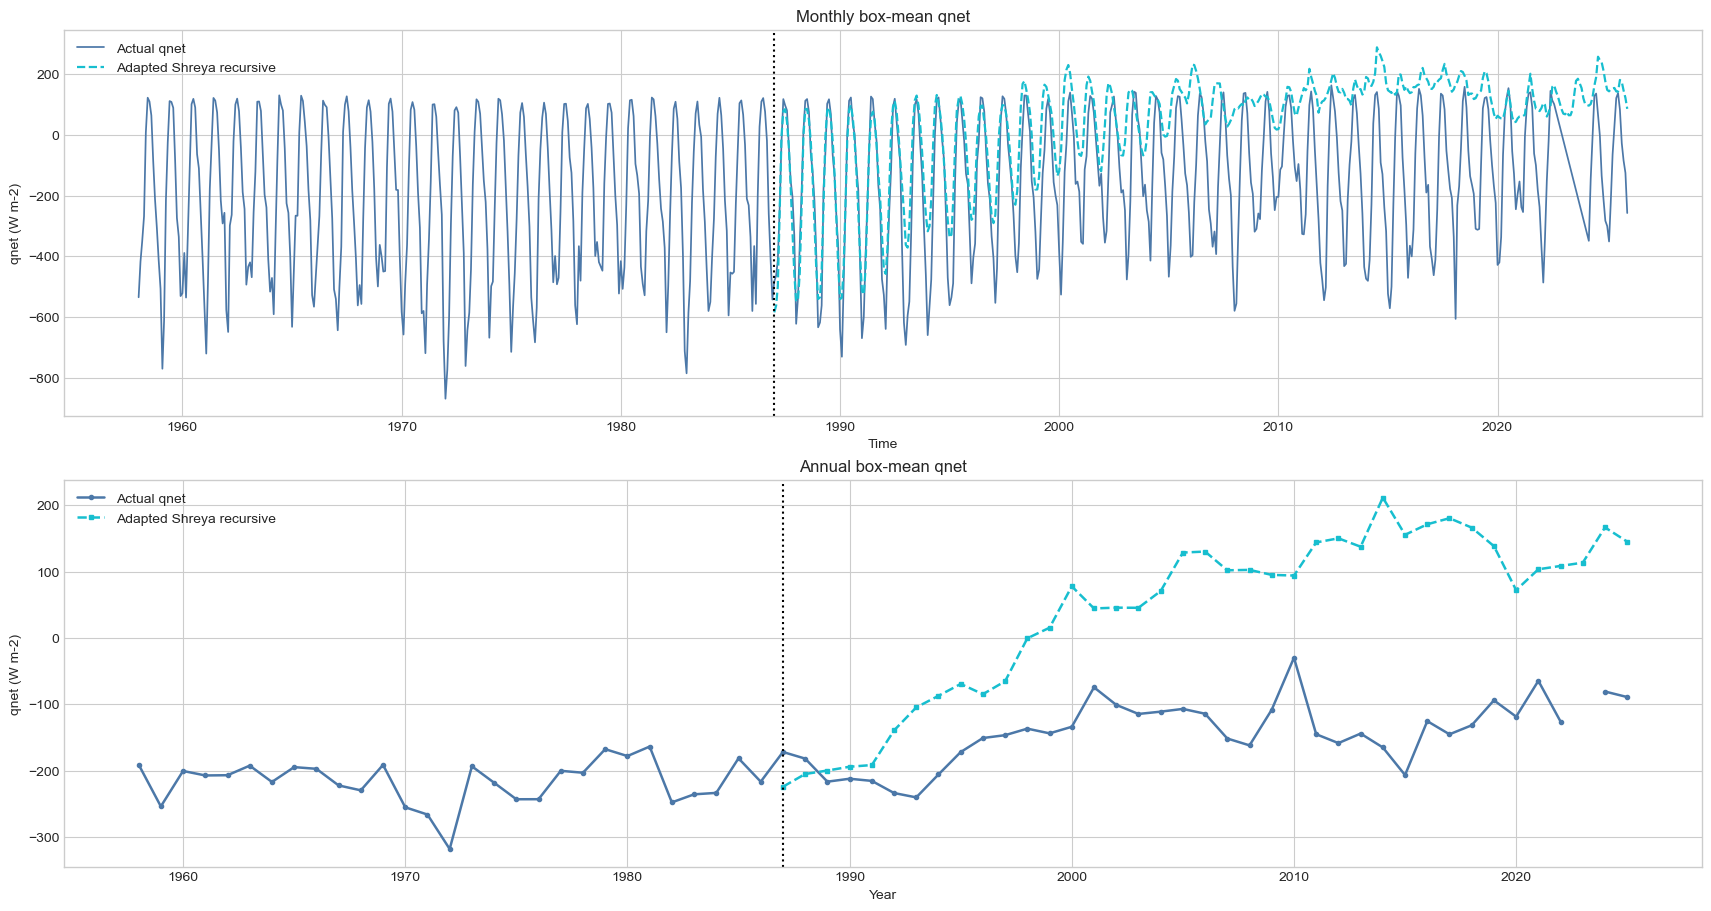

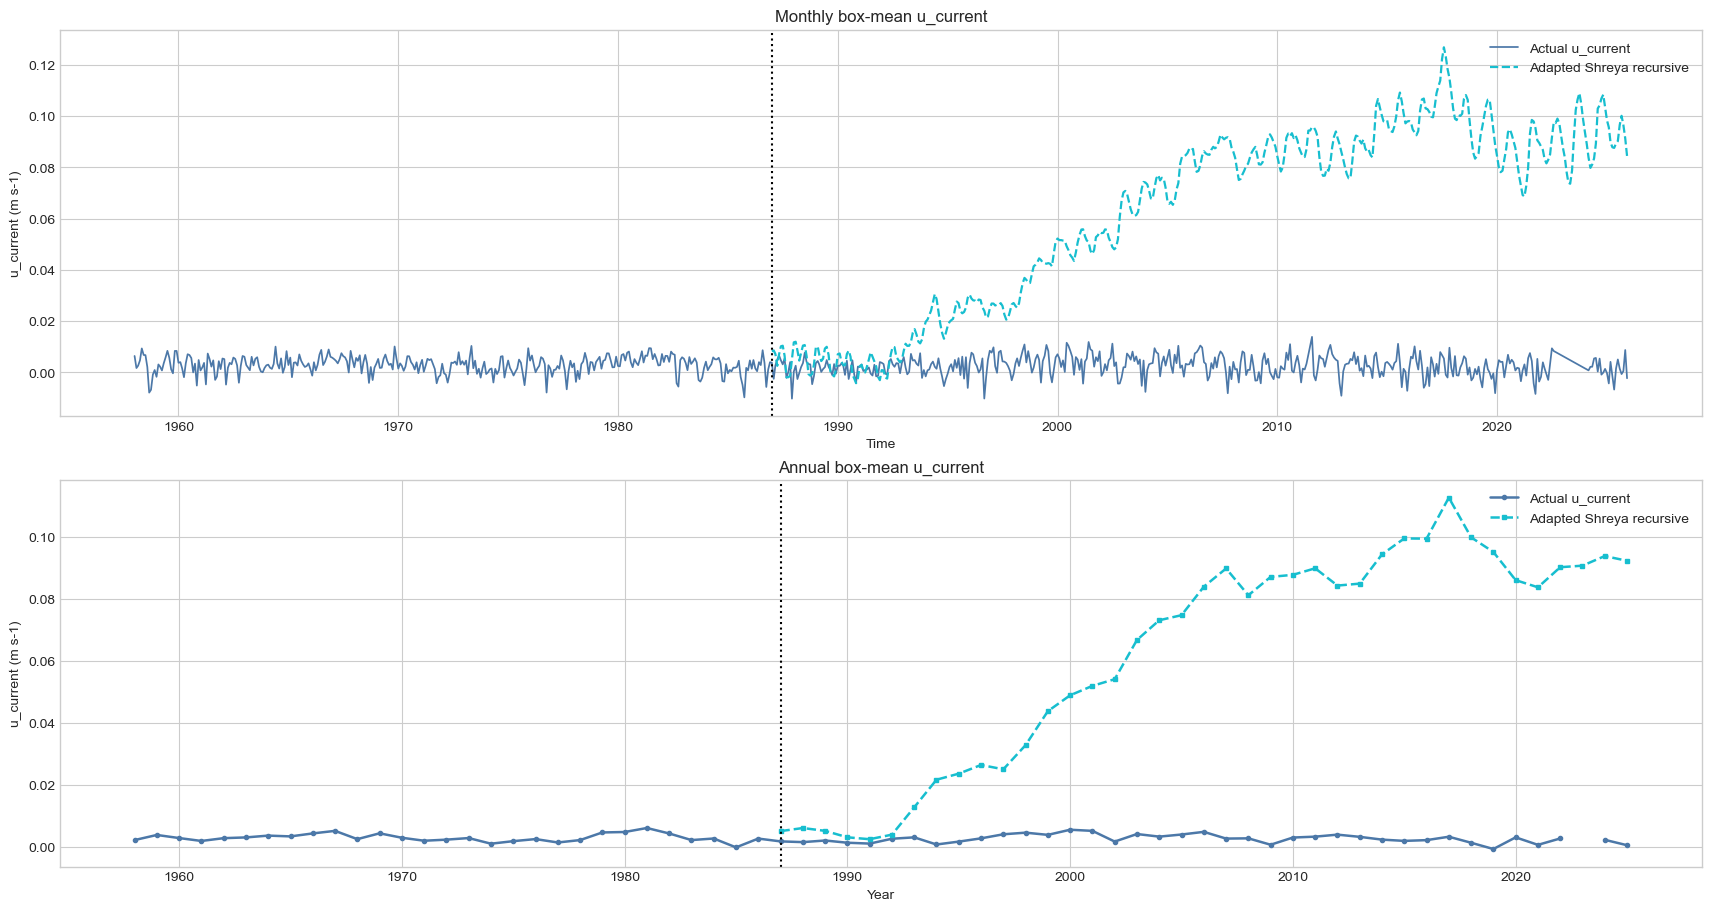

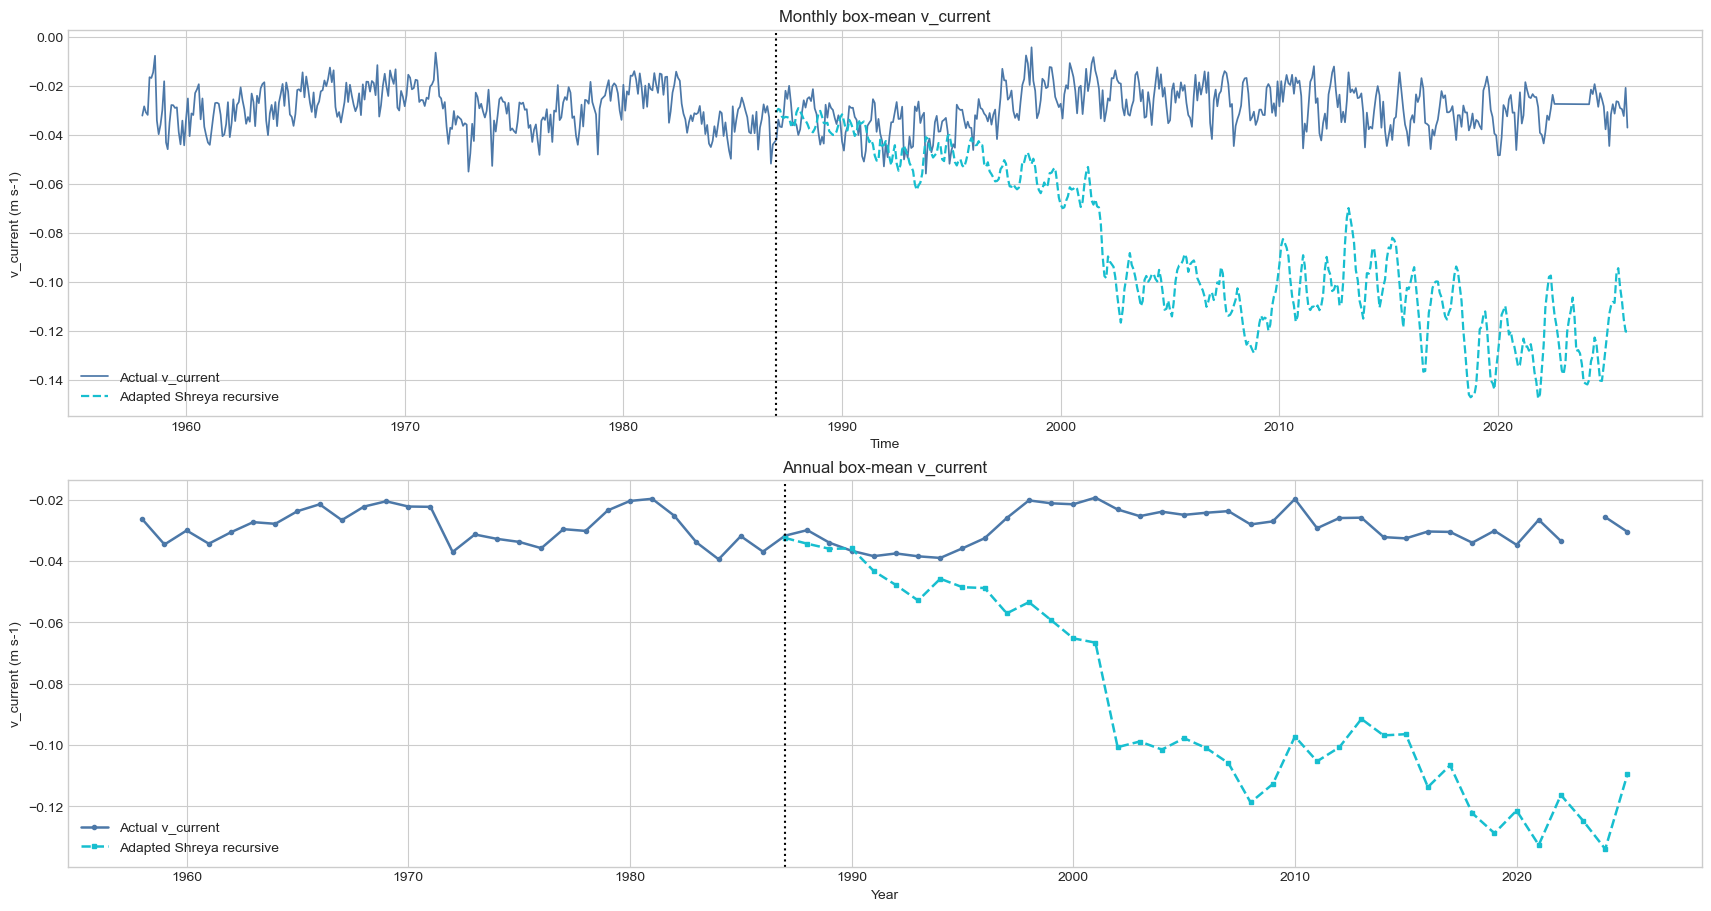

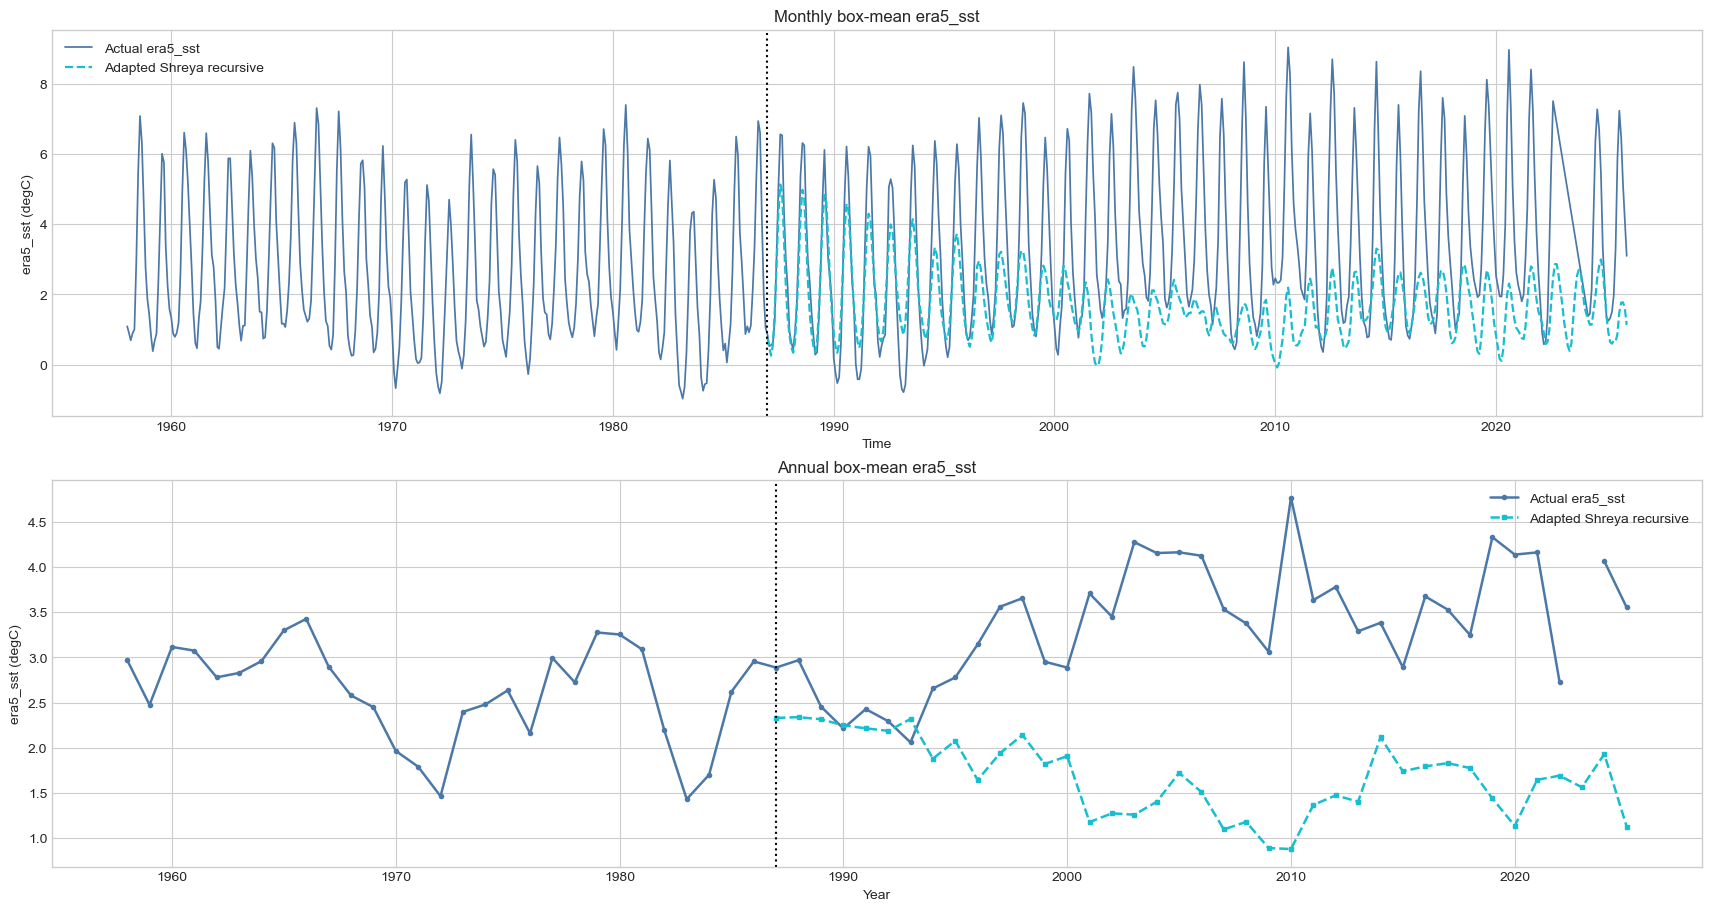

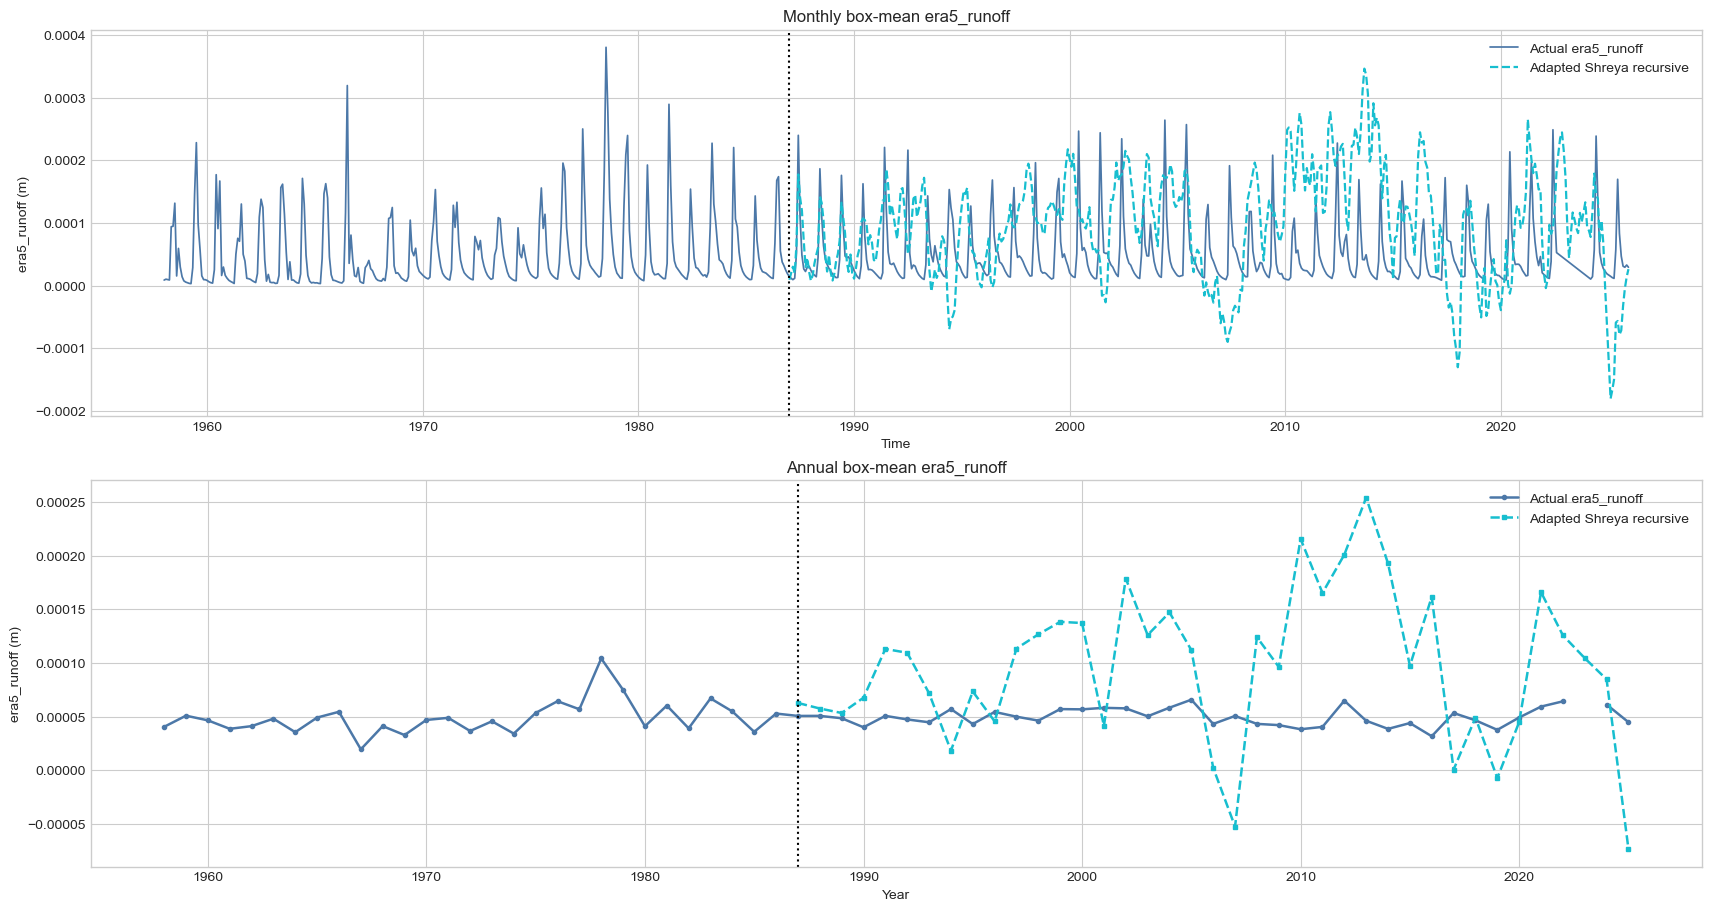

In [16]:
actual_full_box = combined_monthly.sel(feature=convlstm_features).weighted(
    model_lat_weights
).mean(("lat", "lon"), skipna=True)

for feature in convlstm_features:
    unit = FEATURE_UNITS.get(feature, "")
    actual_monthly = pd.Series(
        actual_full_box.sel(feature=feature).values,
        index=pd.DatetimeIndex(pd.to_datetime(actual_full_box.time.values)),
    )
    predicted_monthly = pd.Series(
        predicted_box.sel(feature=feature).values,
        index=forecast_times,
    )
    actual_annual = actual_monthly.resample("YS").mean()
    predicted_annual = predicted_monthly.resample("YS").mean()

    fig, axes = plt.subplots(2, 1, figsize=(17, 9), constrained_layout=True)
    axes[0].plot(actual_monthly.index, actual_monthly, color="#4c78a8", lw=1.25,
                 label=f"Actual {feature}")
    axes[0].plot(predicted_monthly.index, predicted_monthly, color="#17becf", lw=1.6,
                 linestyle="--", label="Adapted Shreya recursive")
    axes[0].axvline(FORECAST_START, color="black", linestyle=":")
    axes[0].set(
        title=f"Monthly box-mean {feature}", xlabel="Time",
        ylabel=f"{feature} ({unit})" if unit else feature,
    )
    axes[0].legend(frameon=False)

    axes[1].plot(actual_annual.index.year, actual_annual, color="#4c78a8", marker="o",
                 ms=3, lw=1.8, label=f"Actual {feature}")
    axes[1].plot(predicted_annual.index.year, predicted_annual, color="#17becf", marker="s",
                 ms=3, lw=1.8, linestyle="--", label="Adapted Shreya recursive")
    axes[1].axvline(SELECTED_INFLECTION_YEAR, color="black", linestyle=":")
    axes[1].set(
        title=f"Annual box-mean {feature}", xlabel="Year",
        ylabel=f"{feature} ({unit})" if unit else feature,
    )
    axes[1].legend(frameon=False)

    safe = re.sub(r"[^A-Za-z0-9_-]+", "_", feature)
    fig.savefig(
        CONVLSTM_DIR / f"adapted_shreya_{safe}_monthly_annual.png",
        dpi=190, bbox_inches="tight",
    )
    plt.show()